# **Eksplorasi Dataset (EDA) | DustiniaDelixia Groceria**
---

### **Persona: Operational Analyst**

|Nama|NRP|Program Studi|
|---|---|---|
|Rahma Sakinah|5025241222|Teknik Informatika|

---

### **Import & Load Data**
---

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [151]:
import warnings
warnings.filterwarnings('ignore')

In [152]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [153]:
DATA_PATH = r'C:\Users\LEGION\Documents\Final_Project_Road_to_Admin_MCI\data\\'


orders = pd.read_csv(DATA_PATH + 'orders.csv')
items = pd.read_csv(DATA_PATH + 'order_items.csv')
sellers = pd.read_csv(DATA_PATH + 'sellers.csv')
customers = pd.read_csv(DATA_PATH + 'customers.csv')
reviews = pd.read_csv(DATA_PATH + 'order_reviews.csv')
payments = pd.read_csv(DATA_PATH + 'order_payments.csv')
products = pd.read_csv(DATA_PATH + 'products.csv')
geo = pd.read_csv(DATA_PATH + 'geolocation.csv')
cat_trans = pd.read_csv(DATA_PATH + 'category_translation.csv')

print(f'orders      : {orders.shape}')
print(f'items       : {items.shape}')
print(f'sellers     : {sellers.shape}')
print(f'customers   : {customers.shape}')
print(f'reviews     : {reviews.shape}')
print(f'payments    : {payments.shape}')
print(f'products    : {products.shape}')
print(f'geo         : {geo.shape}')
print(f'cat_trans   : {cat_trans.shape}')

orders      : (99441, 8)
items       : (112650, 7)
sellers     : (3095, 4)
customers   : (99441, 5)
reviews     : (99224, 7)
payments    : (103886, 5)
products    : (32951, 9)
geo         : (1000163, 5)
cat_trans   : (71, 2)


---
### **Data Overview**
---

In [154]:
# tabel utama: orders
print('--- ORDERS ---')
print(orders.dtypes)
print()
orders.head(3)

--- ORDERS ---
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [155]:
# cek semua tabel sekaligus
dfs = {
    'orders'      : orders,
    'items'       : items,
    'sellers'     : sellers,
    'customers'   : customers,
    'reviews'     : reviews,
    'payments'    : payments,
    'products'    : products,
    'geo'         : geo,
    'cat_trans'   : cat_trans
}

summary = []
for name, df in dfs.items():
    summary.append({
        'Tabel': name,
        'Rows': df.shape[0],
        'Cols': df.shape[1],
        'Missing (total)': df.isnull().sum().sum(),
        'Missing (%)': round(df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100, 2),
        'Duplicates': df.duplicated().sum()
    })

pd.DataFrame(summary)


,Tabel,Rows,Cols,Missing (total),Missing (%),Duplicates
0,orders,99441,8,4908,0.62,0
1,items,112650,7,0,0.00,0
2,sellers,3095,4,0,0.00,0
3,customers,99441,5,0,0.00,0
4,reviews,99224,7,145903,21.01,0
5,payments,103886,5,0,0.00,0
6,products,32951,9,2448,0.83,0
7,geo,1000163,5,0,0.00,261831
8,cat_trans,71,2,0,0.00,0


In [156]:
# missing values per kolom
for name, df in dfs.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'\n------------------------------------')
        print(f'\n{name.upper()}')
        miss_df = missing.reset_index()
        miss_df.columns = ['Kolom', 'Missing Count']
        miss_df['Missing (%)'] = (miss_df['Missing Count'] / len(df) * 100).round(2)
        print(miss_df.to_string(index=False))
    else:
        print(f'\n------------------------------------')
        print(f'\n{name.upper()}: tidak ada missing values')


------------------------------------

ORDERS
                        Kolom  Missing Count  Missing (%)
            order_approved_at            160         0.16
 order_delivered_carrier_date           1783         1.79
order_delivered_customer_date           2965         2.98

------------------------------------

ITEMS: tidak ada missing values

------------------------------------

SELLERS: tidak ada missing values

------------------------------------

CUSTOMERS: tidak ada missing values

------------------------------------

REVIEWS
                 Kolom  Missing Count  Missing (%)
  review_comment_title          87656        88.34
review_comment_message          58247        58.70

------------------------------------

PAYMENTS: tidak ada missing values

------------------------------------

PRODUCTS
                     Kolom  Missing Count  Missing (%)
     product_category_name            610         1.85
       product_name_lenght            610         1.85
product_descript

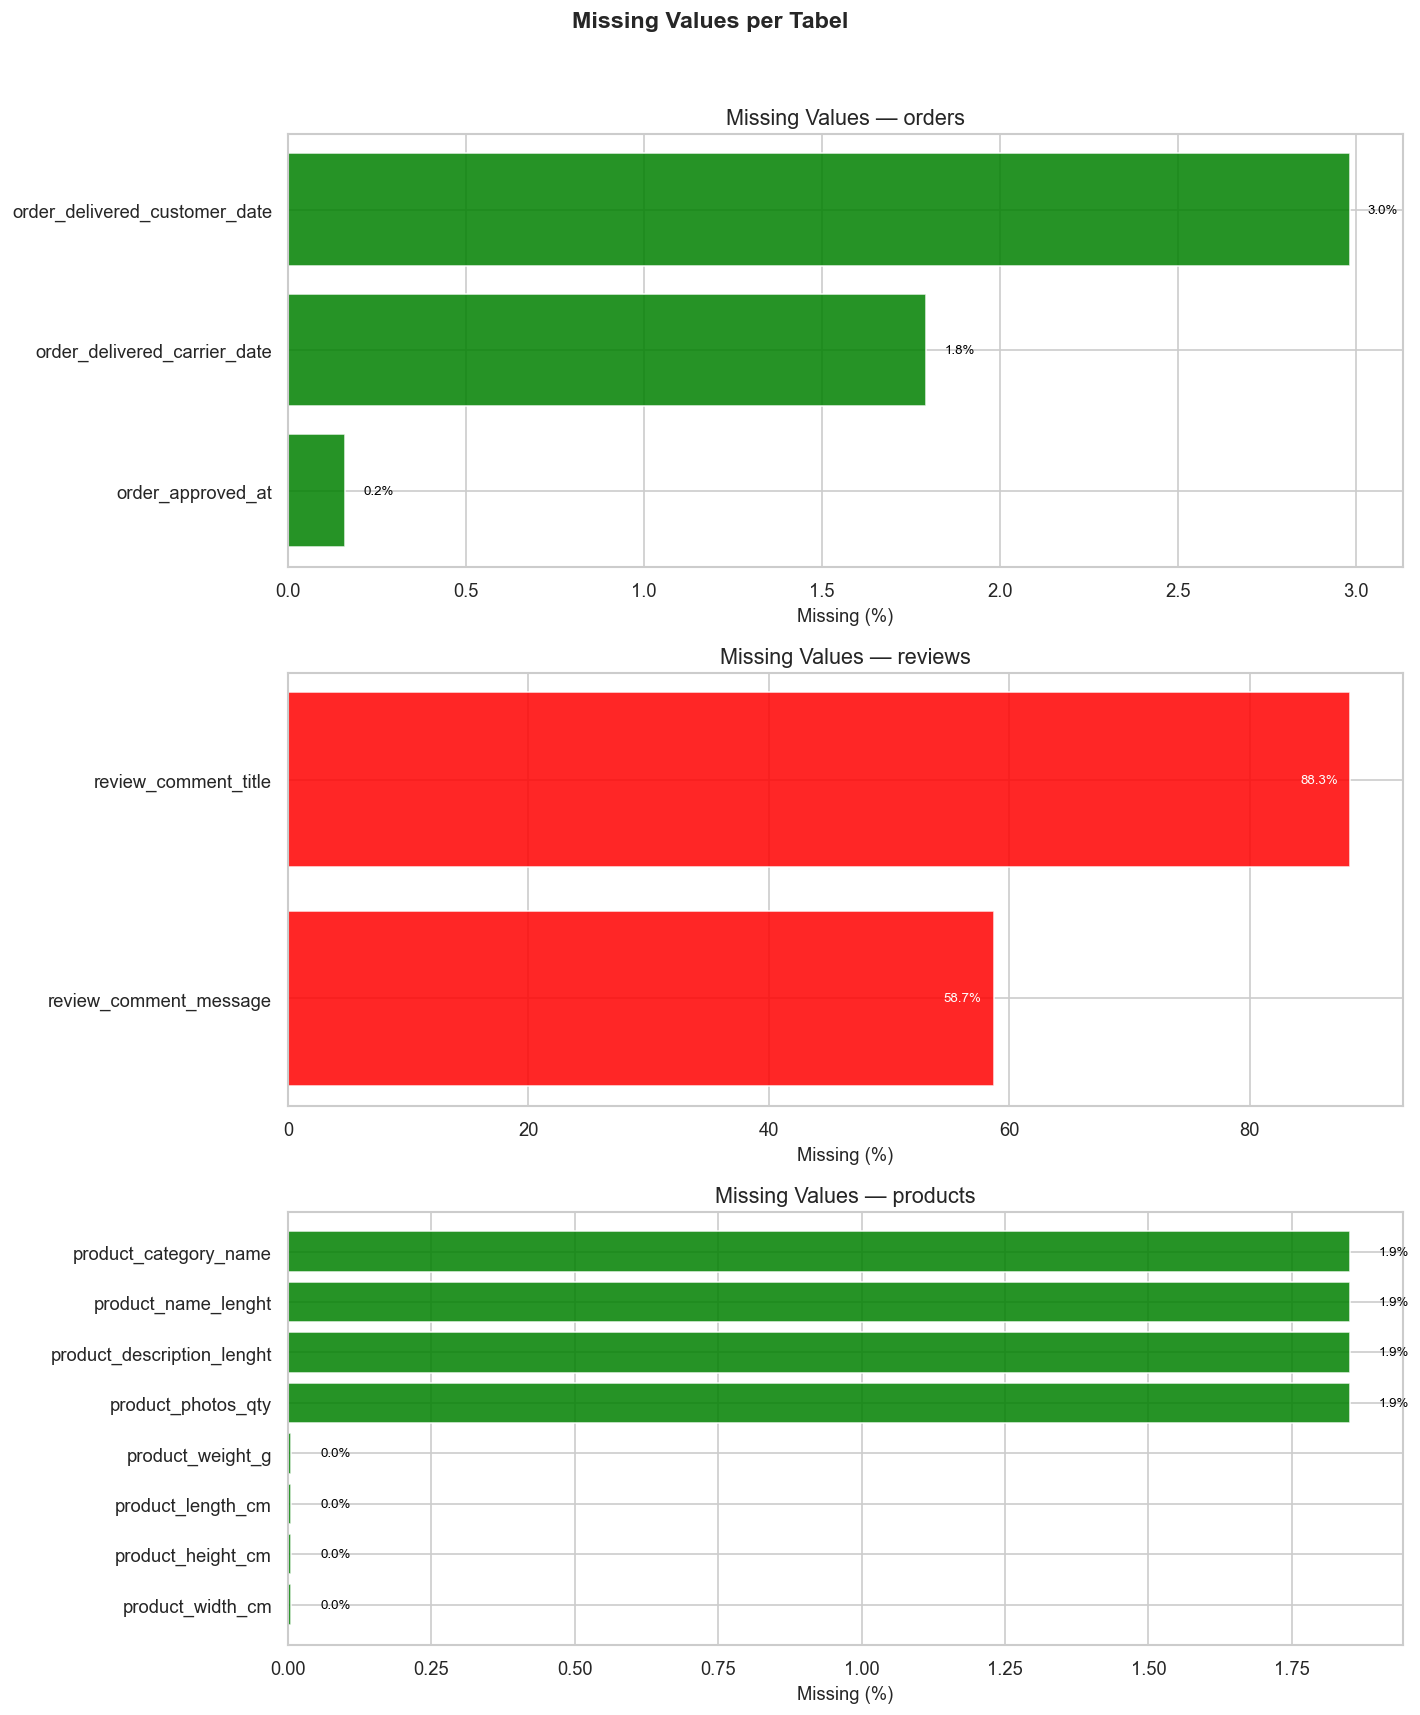

In [157]:
# visualisasi missing values — semua tabel yang ada missing
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
axes = axes.flatten()

tables_with_missing = {
    'orders'  : orders,
    'reviews' : reviews,
    'products': products
}

for i, (name, df) in enumerate(tables_with_missing.items()):
    miss = df.isnull().mean() * 100
    miss = miss[miss > 0].sort_values()
    
    colors = ['red' if v >= 20 else 'orange' if v >= 5 else 'green' for v in miss.values]
    
    bars = axes[i].barh(miss.index, miss.values, color=colors, alpha=0.85)
    axes[i].set_title(f'Missing Values — {name}')
    axes[i].set_xlabel('Missing (%)')
    
    for bar, v in zip(bars, miss.values):
        if v >= 5:
            # Label di dalam bar
            axes[i].text(bar.get_width() - 1, bar.get_y() + bar.get_height()/2,
                        f'{v:.1f}%', va='center', ha='right', fontsize=8, color='white')
        else:
            # Label di luar bar (bar terlalu pendek)
            axes[i].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                        f'{v:.1f}%', va='center', ha='left', fontsize=8, color='black')

plt.suptitle('Missing Values per Tabel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

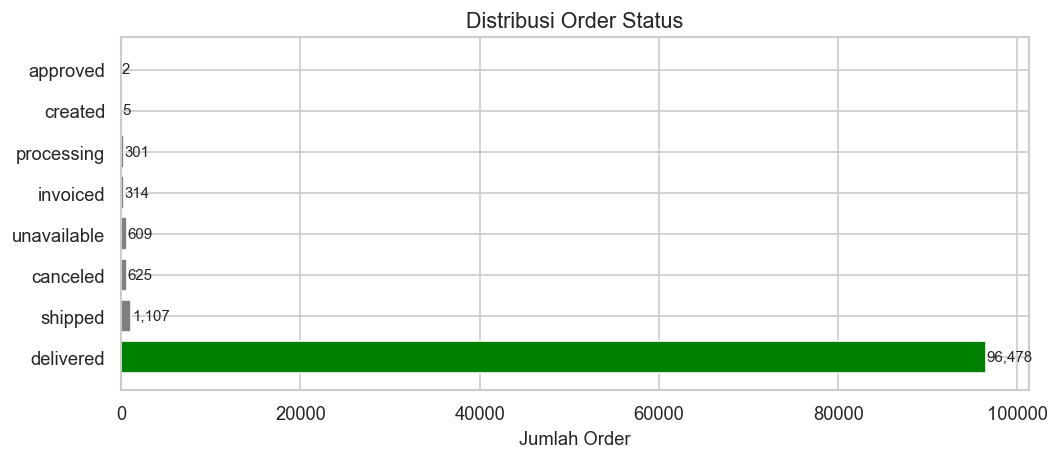


Total orders: 99,441
Delivered: 96,478 (97.0%)
Non-delivered: 2,963


In [158]:
# distribusi Order Status
fig, ax = plt.subplots(figsize=(9, 4))
status_counts = orders['order_status'].value_counts()
colors = ['green' if s == 'delivered' else 'gray' for s in status_counts.index]
bars = ax.barh(status_counts.index, status_counts.values, color=colors)
ax.set_xlabel('Jumlah Order')
ax.set_title('Distribusi Order Status')
for bar, v in zip(bars, status_counts.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nTotal orders: {len(orders):,}')
print(f'Delivered: {status_counts["delivered"]:,} ({status_counts["delivered"]/len(orders)*100:.1f}%)')
print(f'Non-delivered: {len(orders) - status_counts["delivered"]:,}')


---

### **Preprocessing**

---

In [159]:
# parse semua timestamp
ts_cols = ['order_purchase_timestamp','order_approved_at',
           'order_delivered_carrier_date','order_delivered_customer_date',
           'order_estimated_delivery_date']

for col in ts_cols:
    orders[col] = pd.to_datetime(orders[col])

# filter hanya delivered
delivered = orders[orders['order_status'] == 'delivered'].copy()

# derived columns
# durasi per stage (dalam jam)
delivered['t1_approval_h'] = (delivered['order_approved_at'] - delivered['order_purchase_timestamp']).dt.total_seconds() / 3600
delivered['t2_processing_h'] = (delivered['order_delivered_carrier_date'] - delivered['order_approved_at']).dt.total_seconds() / 3600
delivered['t3_shipping_h'] = (delivered['order_delivered_customer_date'] - delivered['order_delivered_carrier_date']).dt.total_seconds() / 3600

# total delivery (dalam hari)
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['estimated_days'] = (delivered['order_estimated_delivery_date'] - delivered['order_purchase_timestamp']).dt.days

# flag keterlambatan
delivered['is_late'] = delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']
delivered['days_late'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days

# rasio aktual vs estimasi
delivered['actual_vs_est_ratio'] = delivered['delivery_days'] / delivered['estimated_days']

# fitur waktu
delivered['purchase_month'] = delivered['order_purchase_timestamp'].dt.month
delivered['purchase_dayofweek'] = delivered['order_purchase_timestamp'].dt.dayofweek
delivered['purchase_hour'] = delivered['order_purchase_timestamp'].dt.hour

print(f'Delivered orders: {len(delivered):,}')
print(f'Late orders     : {delivered["is_late"].sum():,} ({delivered["is_late"].mean()*100:.1f}%)')
print(f'On-time orders  : {(~delivered["is_late"]).sum():,} ({(~delivered["is_late"]).mean()*100:.1f}%)')
print()
print('Derived columns:')
derived_cols = ['t1_approval_h','t2_processing_h','t3_shipping_h', 'delivery_days','estimated_days','is_late','days_late', 'actual_vs_est_ratio']
print(delivered[derived_cols].describe().round(2))


Delivered orders: 96,478
Late orders     : 7,826 (8.1%)
On-time orders  : 88,652 (91.9%)

Derived columns:
       t1_approval_h  t2_processing_h  t3_shipping_h  delivery_days  \
count       96464.00         96462.00       96469.00       96470.00   
mean           10.28            67.18         223.93          12.09   
std            20.54            84.89         210.24           9.55   
min             0.00         -4109.26        -386.31           0.00   
25%             0.22            20.98          98.40           6.00   
50%             0.34            43.58         170.39          10.00   
75%            14.51            85.80         288.69          15.00   
max           741.44          3018.30        4924.58         209.00   

       estimated_days  days_late  actual_vs_est_ratio  
count        96478.00   96470.00             96470.00  
mean            23.37     -11.88                 0.53  
std              8.76      10.18                 0.39  
min              2.00    -147

---

### **Univariate Analysis**

---

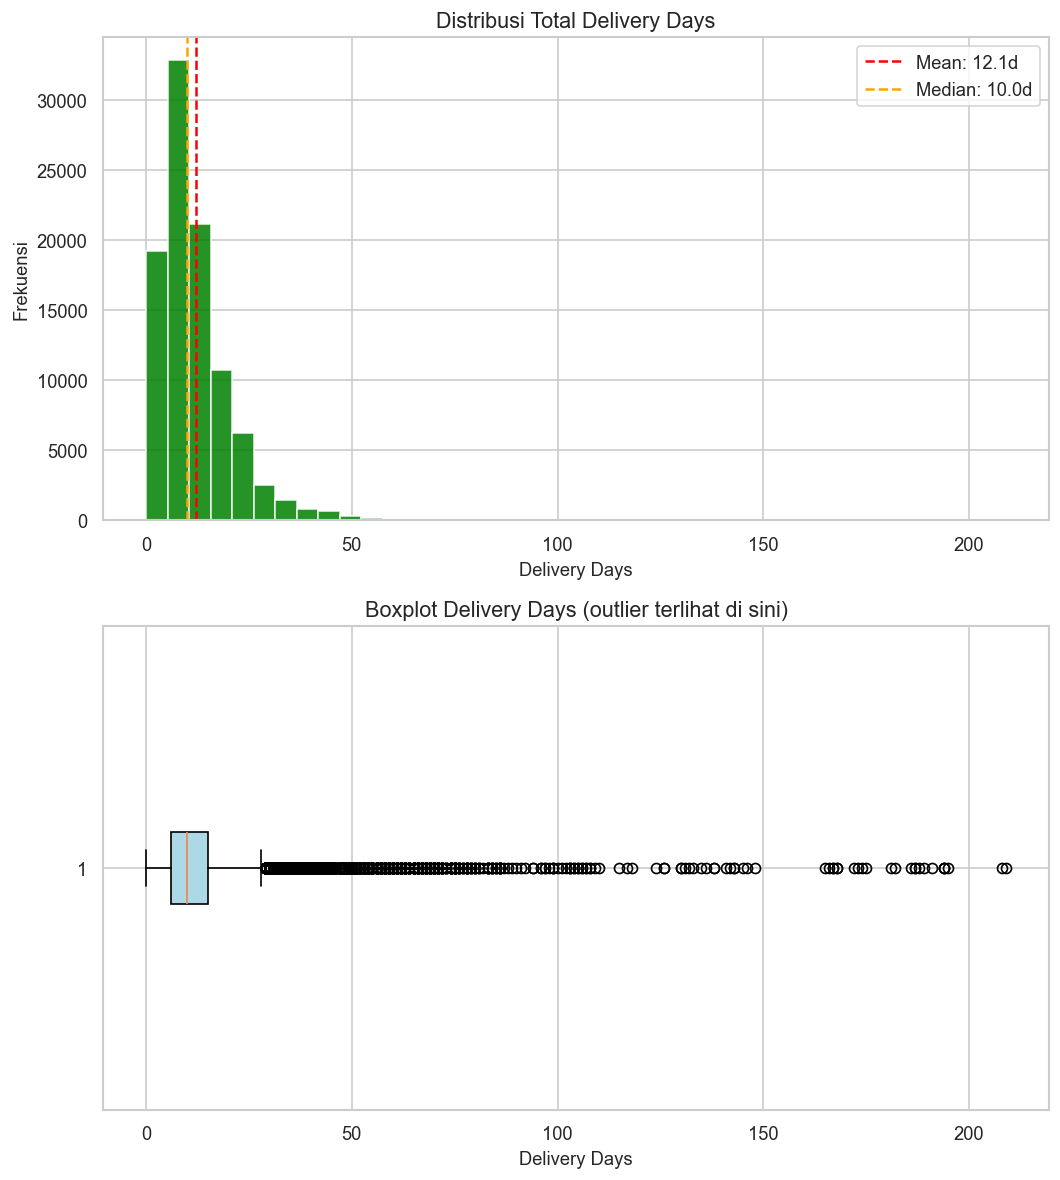

Statistik delivery_days:
count    96470.00
mean        12.09
std          9.55
min          0.00
25%          6.00
50%         10.00
75%         15.00
max        209.00
Name: delivery_days, dtype: float64


In [160]:
# distribusi delivery days
fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# histogram
axes[0].hist(delivered['delivery_days'].dropna(), bins=40, color='green', edgecolor='white', alpha=0.85)
axes[0].axvline(delivered['delivery_days'].mean(), color='red', linestyle='--', label=f'Mean: {delivered["delivery_days"].mean():.1f}d')
axes[0].axvline(delivered['delivery_days'].median(), color='orange', linestyle='--', label=f'Median: {delivered["delivery_days"].median():.1f}d')
axes[0].set_xlabel('Delivery Days')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Total Delivery Days')
axes[0].legend()

# boxplot
axes[1].boxplot(delivered['delivery_days'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_xlabel('Delivery Days')
axes[1].set_title('Boxplot Delivery Days (outlier terlihat di sini)')

plt.tight_layout()
plt.show()

print('Statistik delivery_days:')
print(delivered['delivery_days'].describe().round(2))


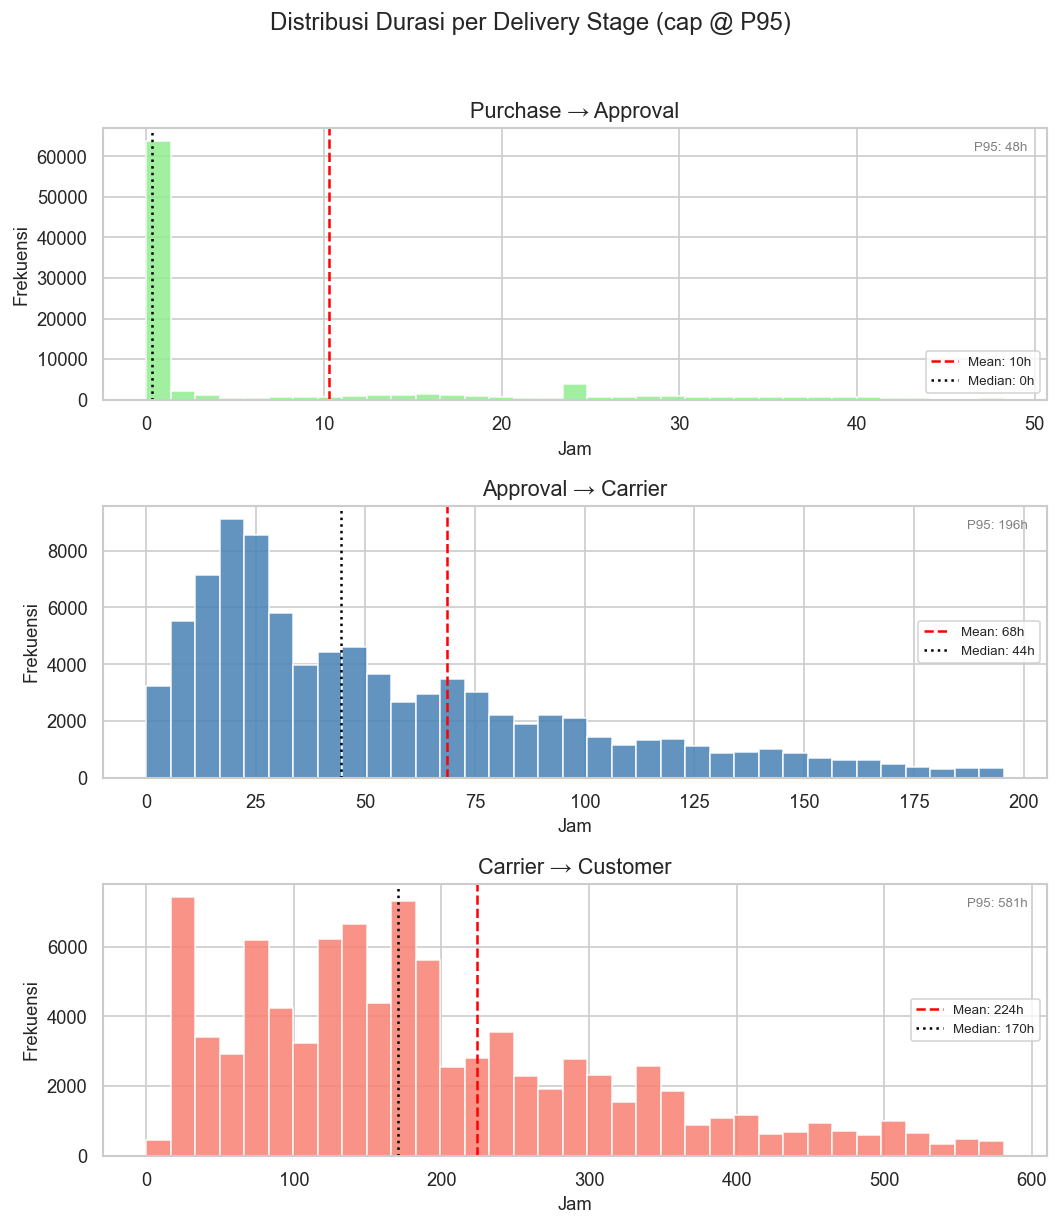

In [161]:
# distribusi per stage — t1, t2, t3
fig, axes = plt.subplots(3, 1, figsize=(9, 10))

stage_info = [
    ('t1_approval_h',   'Purchase → Approval', 'lightgreen'),
    ('t2_processing_h', 'Approval → Carrier',  'steelblue'),
    ('t3_shipping_h',   'Carrier → Customer',  'salmon'),
]

for ax, (col, label, color) in zip(axes, stage_info):
    data = delivered[col].dropna()
    data = data[data >= 0]
    cap = data.quantile(0.95)
    ax.hist(data[data <= cap], bins=35, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.0f}h')
    ax.axvline(data.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {data.median():.0f}h')
    ax.set_title(label)
    ax.set_xlabel('Jam')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.text(0.98, 0.95, f'P95: {cap:.0f}h', transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.suptitle('Distribusi Durasi per Delivery Stage (cap @ P95)', y=1.02)
plt.tight_layout()
plt.show()


In [162]:
# statistik per stage
stages = {
    'Purchase→Approval': delivered['t1_approval_h'][delivered['t1_approval_h'] >= 0],
    'Approval→Carrier' : delivered['t2_processing_h'][delivered['t2_processing_h'] >= 0],
    'Carrier→Customer' : delivered['t3_shipping_h'][delivered['t3_shipping_h'] >= 0],
}

stage_stats = []
for label, s in stages.items():
    stage_stats.append({
        'Stage': label,
        'Mean (h)': round(s.mean(), 1),
        'Median (h)': round(s.median(), 1),
        'P95 (h)': round(s.quantile(0.95), 1),
        'Max (h)': round(s.max(), 1),
        'Max (hari)': round(s.max()/24, 1)
    })

pd.DataFrame(stage_stats)

,Stage,Mean (h),Median (h),P95 (h),Max (h),Max (hari)
0,Purchase→Approval,10.3,0.3,48.3,741.4,30.9
1,Approval→Carrier,68.5,44.4,195.5,3018.3,125.8
2,Carrier→Customer,224.0,170.4,581.0,4924.6,205.2


---

### **Late Delivery Analysis**

---

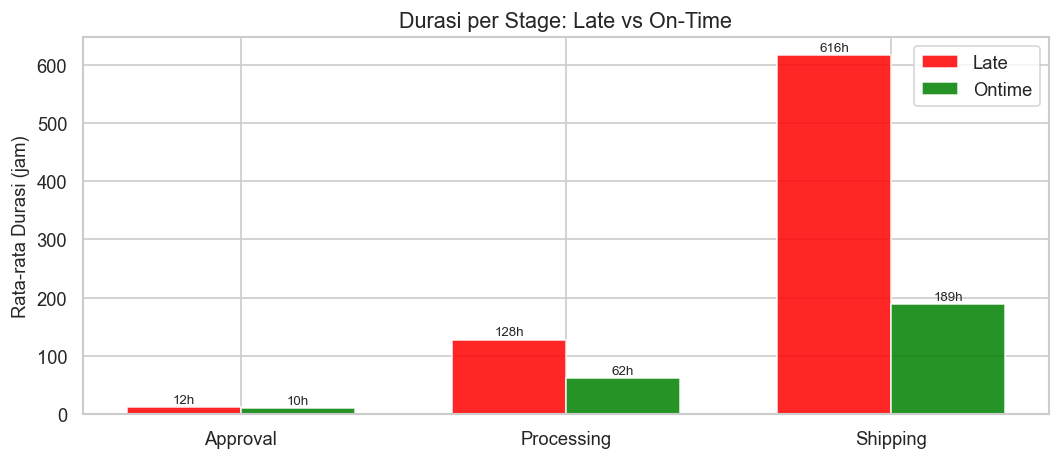

Kontribusi stage ke keterlambatan:
     Stage  Selisih (h)  Selisih (hari)
  Approval          2.2             0.1
Processing         65.9             2.7
  Shipping        427.1            17.8


In [163]:
# late vs On-Time per stage
late   = delivered[delivered['is_late'] == True]
ontime = delivered[delivered['is_late'] == False]

stages_comp = pd.DataFrame({
    'Stage': ['Approval', 'Processing', 'Shipping'],
    'Late (mean h)': [
        late['t1_approval_h'].mean(),
        late['t2_processing_h'].mean(),
        late['t3_shipping_h'].mean()
    ],
    'Ontime (mean h)': [
        ontime['t1_approval_h'].mean(),
        ontime['t2_processing_h'].mean(),
        ontime['t3_shipping_h'].mean()
    ]
})
stages_comp['Selisih (h)'] = stages_comp['Late (mean h)'] - stages_comp['Ontime (mean h)']
stages_comp['Selisih (hari)'] = (stages_comp['Selisih (h)'] / 24).round(1)
stages_comp = stages_comp.round(1)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(stages_comp))
w = 0.35
b1 = ax.bar([i - w/2 for i in x], stages_comp['Late (mean h)'],  w, label='Late',   color='red', alpha=0.85)
b2 = ax.bar([i + w/2 for i in x], stages_comp['Ontime (mean h)'], w, label='Ontime', color='green', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(stages_comp['Stage'])
ax.set_ylabel('Rata-rata Durasi (jam)')
ax.set_title('Durasi per Stage: Late vs On-Time')
ax.legend()
for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{bar.get_height():.0f}h', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print('Kontribusi stage ke keterlambatan:')
print(stages_comp[['Stage','Selisih (h)','Selisih (hari)']].to_string(index=False))


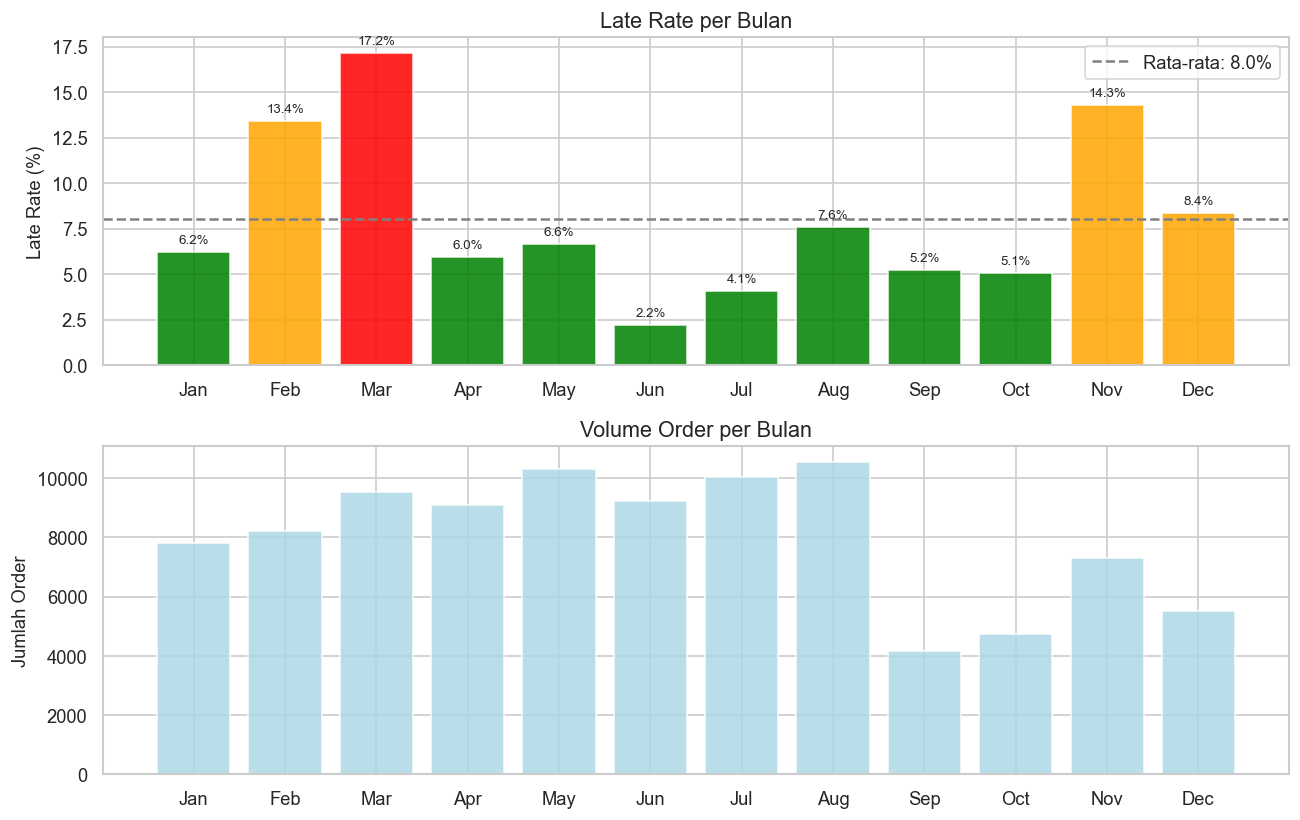

In [164]:
# late rate per bulan
month_stats = delivered.groupby('purchase_month').agg(
    total=('order_id','count'),
    late_count=('is_late','sum'),
    late_rate=('is_late','mean'),
    avg_days=('delivery_days','mean')
).reset_index()
month_stats['late_rate_pct'] = month_stats['late_rate'] * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_stats['bulan'] = month_stats['purchase_month'].apply(lambda x: month_names[x-1])

fig, axes = plt.subplots(2, 1, figsize=(11, 7))

# late rate
colors = ['red' if v >= 15 else 'orange' if v >= 8 else 'green'
          for v in month_stats['late_rate_pct']]
axes[0].bar(month_stats['bulan'], month_stats['late_rate_pct'], color=colors, alpha=0.85)
axes[0].set_ylabel('Late Rate (%)')
axes[0].set_title('Late Rate per Bulan')
axes[0].axhline(month_stats['late_rate_pct'].mean(), color='gray',
                linestyle='--', label=f'Rata-rata: {month_stats["late_rate_pct"].mean():.1f}%')
axes[0].legend()
for i, (_, row) in enumerate(month_stats.iterrows()):
    axes[0].text(i, row['late_rate_pct'] + 0.3, f'{row["late_rate_pct"]:.1f}%',
                 ha='center', va='bottom', fontsize=8)

# volume order
axes[1].bar(month_stats['bulan'], month_stats['total'], color='lightblue', alpha=0.85)
axes[1].set_ylabel('Jumlah Order')
axes[1].set_title('Volume Order per Bulan')

plt.tight_layout()
plt.show()


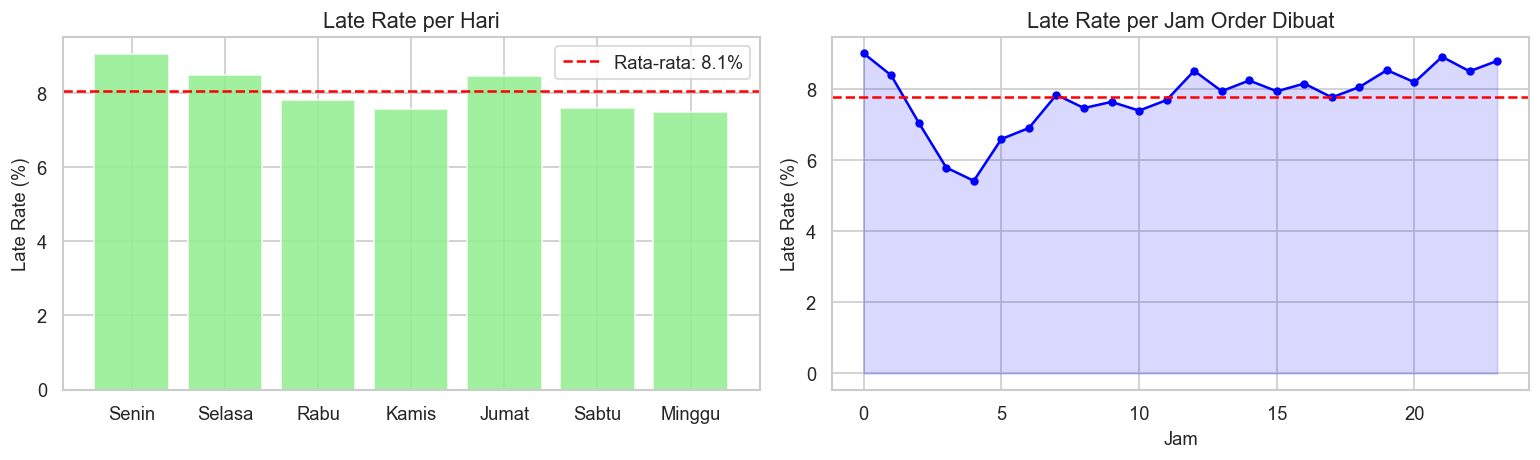

In [165]:
# late rate per hari & jam
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# day of week
dow_stats = delivered.groupby('purchase_dayofweek')['is_late'].mean() * 100
dow_labels = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
axes[0].bar(dow_labels, dow_stats.values, color='lightgreen', alpha=0.85, edgecolor='white')
axes[0].set_ylabel('Late Rate (%)')
axes[0].set_title('Late Rate per Hari')
axes[0].axhline(dow_stats.mean(), color='red', linestyle='--',
                label=f'Rata-rata: {dow_stats.mean():.1f}%')
axes[0].legend()

# hour of day
hour_stats = delivered.groupby('purchase_hour')['is_late'].mean() * 100
axes[1].plot(hour_stats.index, hour_stats.values, color='blue', marker='o', markersize=4)
axes[1].fill_between(hour_stats.index, hour_stats.values, alpha=0.15, color='blue')
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Late Rate (%)')
axes[1].set_title('Late Rate per Jam Order Dibuat')
axes[1].axhline(hour_stats.mean(), color='red', linestyle='--')

plt.tight_layout()
plt.show()


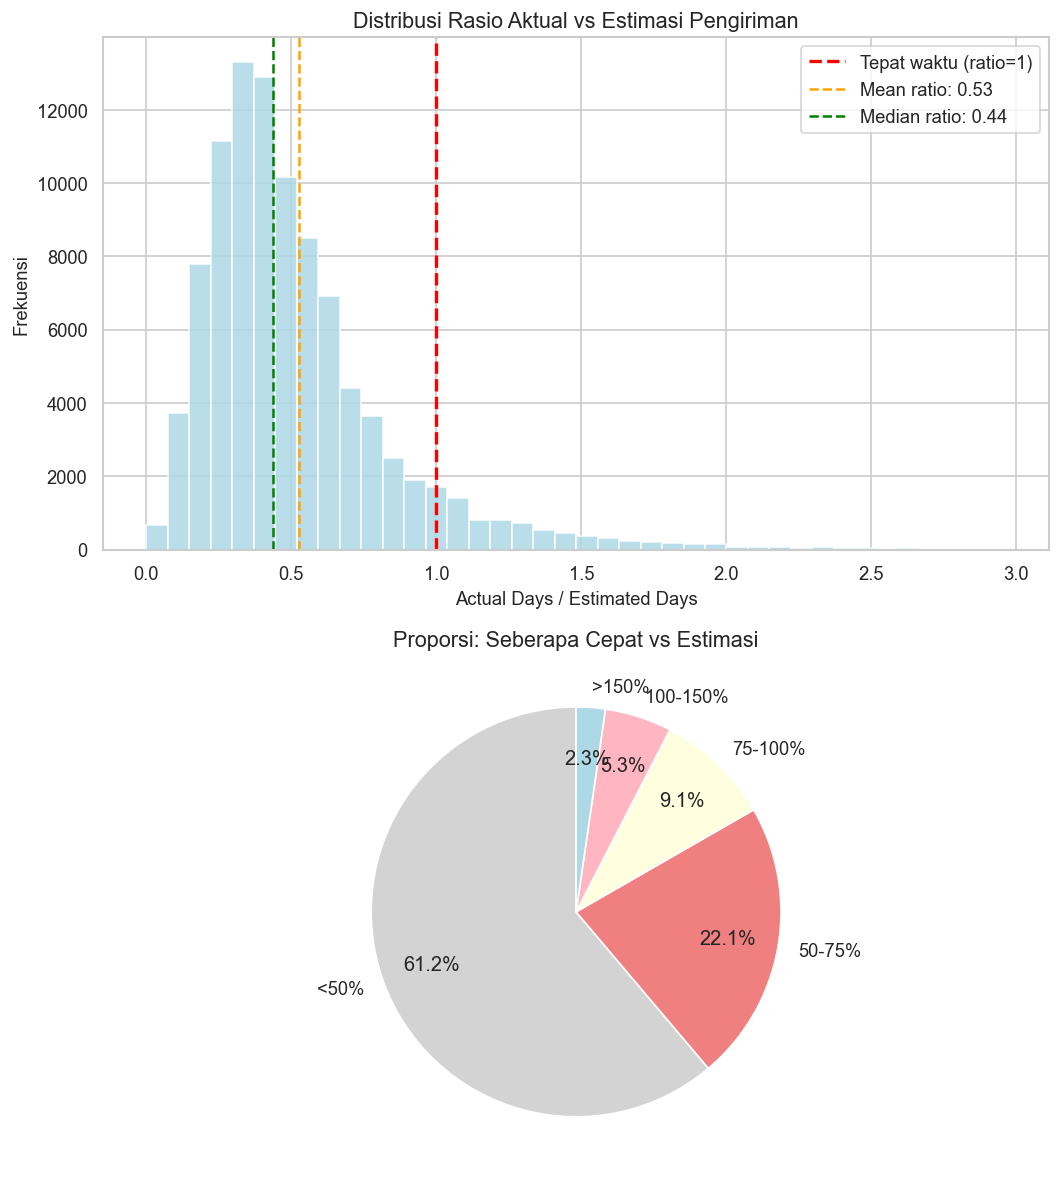


Order tiba dalam <50% estimasi waktu: 55,741 (57.8%)
Order tiba LEBIH LAMA dari estimasi : 7,307 (7.6%)


In [166]:
# rasio actual vs estimasi
ratio = delivered['actual_vs_est_ratio'].dropna()
ratio_clean = ratio[ratio < 3]  # cap untuk visualisasi

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

axes[0].hist(ratio_clean, bins=40, color='lightblue', edgecolor='white', alpha=0.85)
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Tepat waktu (ratio=1)')
axes[0].axvline(ratio.mean(), color='orange', linestyle='--', label=f'Mean ratio: {ratio.mean():.2f}')
axes[0].axvline(ratio.median(), color='green', linestyle='--', label=f'Median ratio: {ratio.median():.2f}')
axes[0].set_xlabel('Actual Days / Estimated Days')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Rasio Aktual vs Estimasi Pengiriman')
axes[0].legend()

# pie chart — kategorisasi
buckets = pd.cut(ratio, bins=[0, 0.5, 0.75, 1.0, 1.5, 20], labels=['<50%', '50-75%', '75-100%', '100-150%', '>150%'])
bucket_counts = buckets.value_counts().sort_index()
colors_pie = ['lightgray','lightcoral','lightyellow','lightpink','lightblue']
axes[1].pie(bucket_counts.values, labels=bucket_counts.index, colors=colors_pie, autopct='%1.1f%%', startangle=90, pctdistance=0.75)
axes[1].set_title('Proporsi: Seberapa Cepat vs Estimasi')

plt.tight_layout()
plt.show()

print(f'\nOrder tiba dalam <50% estimasi waktu: {(ratio < 0.5).sum():,} ({(ratio < 0.5).mean()*100:.1f}%)')
print(f'Order tiba LEBIH LAMA dari estimasi : {(ratio > 1.0).sum():,} ({(ratio > 1.0).mean()*100:.1f}%)')


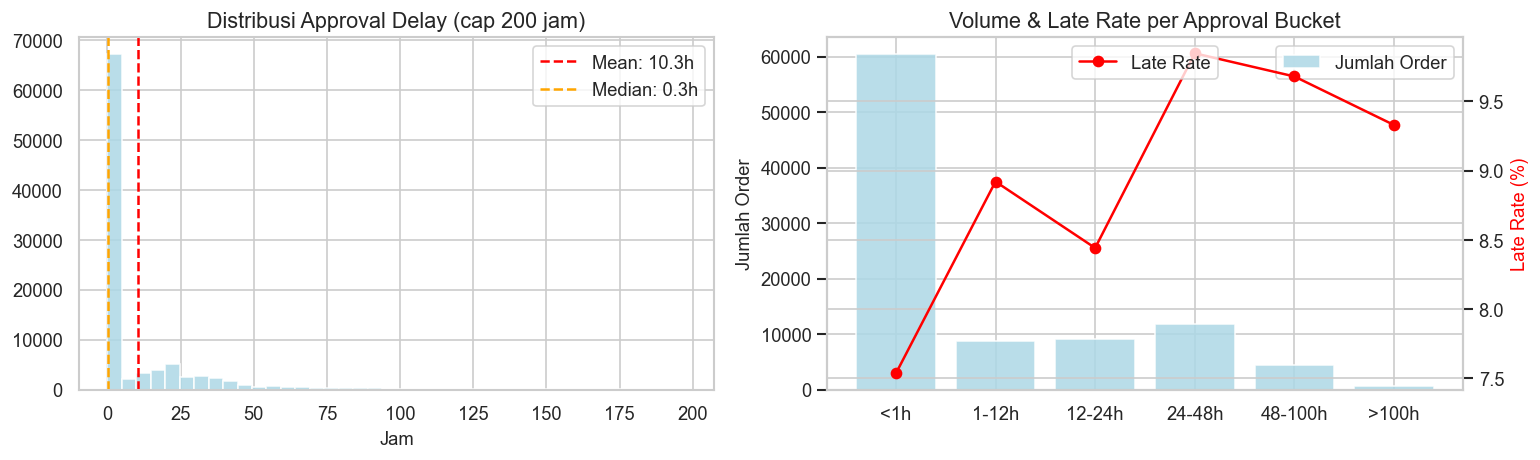


Approval delay max : 741.4 jam = 30.9 hari (!)
Order dengan approval >24h : 16,873 (17.5%)


In [167]:
# distribusi approval delay + highlight anomali
t1 = delivered['t1_approval_h'].dropna()
t1_cap = t1[t1 <= 200]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(t1_cap, bins=40, color='lightblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Jam')
axes[0].set_title('Distribusi Approval Delay (cap 200 jam)')
axes[0].axvline(t1.mean(), color='red', linestyle='--', label=f'Mean: {t1.mean():.1f}h')
axes[0].axvline(t1.median(), color='orange', linestyle='--', label=f'Median: {t1.median():.1f}h')
axes[0].legend()

# bucket breakdown
buckets_t1 = pd.cut(t1, bins=[0, 1, 12, 24, 48, 100, t1.max()], labels=['<1h','1-12h','12-24h','24-48h','48-100h','>100h'])
b_counts = buckets_t1.value_counts().sort_index()
late_by_bucket = delivered.groupby(buckets_t1, observed=True)['is_late'].mean() * 100

ax2 = axes[1]
x = range(len(b_counts))
bars = ax2.bar(list(x), b_counts.values, color='lightblue', alpha=0.85, label='Jumlah Order')
ax2_twin = ax2.twinx()
ax2_twin.plot(list(x), late_by_bucket.values, color='red', marker='o', label='Late Rate')
ax2.set_xticks(list(x))
ax2.set_xticklabels(b_counts.index)
ax2.set_ylabel('Jumlah Order')
ax2_twin.set_ylabel('Late Rate (%)', color='red')
ax2.set_title('Volume & Late Rate per Approval Bucket')
ax2.legend(loc='upper right')
ax2_twin.legend(loc='upper center')

plt.tight_layout()
plt.show()

print(f'\nApproval delay max : {t1.max():.1f} jam = {t1.max()/24:.1f} hari (!)')
print(f'Order dengan approval >24h : {(t1>24).sum():,} ({(t1>24).mean()*100:.1f}%)')


In [168]:
# anomali ekstrem approval delay
t1 = delivered['t1_approval_h'].dropna()

ekstrem = delivered[delivered['t1_approval_h'] > 100]
print(f'Order dengan approval delay >100 jam : {len(ekstrem):,} ({len(ekstrem)/len(delivered)*100:.1f}%)')
print(f'Order dengan approval delay >200 jam : {(t1>200).sum():,} ({(t1>200).mean()*100:.1f}%)')
print(f'Order dengan approval delay >500 jam : {(t1>500).sum():,} ({(t1>500).mean()*100:.1f}%)')
print(f'Order dengan approval delay = MAX (741 jam): {(t1==t1.max()).sum():,} order')
print()
print('Detail 5 order dengan approval delay terlama:')
worst_approval = delivered.nlargest(5, 't1_approval_h')[['order_id','order_purchase_timestamp','order_approved_at','t1_approval_h','is_late']]
worst_approval['t1_hari'] = (worst_approval['t1_approval_h'] / 24).round(1)
print(worst_approval.to_string(index=False))

Order dengan approval delay >100 jam : 611 (0.6%)
Order dengan approval delay >200 jam : 46 (0.0%)
Order dengan approval delay >500 jam : 3 (0.0%)
Order dengan approval delay = MAX (741 jam): 1 order

Detail 5 order dengan approval delay terlama:
                        order_id order_purchase_timestamp   order_approved_at  t1_approval_h  is_late  t1_hari
0a93b40850d3f4becf2f276666e01340      2018-01-20 14:24:50 2018-02-20 11:51:27     741.443611     True     30.9
f7923db0430587601c2aef15ec4b8af4      2018-01-20 17:38:58 2018-02-20 12:05:54     738.448889     True     30.8
de0076b42a023f53b398ce9ab0d9009c      2017-12-04 11:15:54 2017-12-27 14:03:00     554.785000     True     23.1
daed0f3aefd193de33c31e21b16a3b3a      2018-03-12 15:21:32 2018-03-29 11:35:16     404.228889     True     16.8
9c038e10f14d12a96939a0176c4ecc99      2017-05-26 15:30:49 2017-06-08 23:02:47     319.532778    False     13.3


---

### **Seller Performance Analysis**

---

Total sellers        : 2,970
High-volume (>=20)   : 804
Perfect (0% late)    : 73
Kronis (>20% late)   : 33



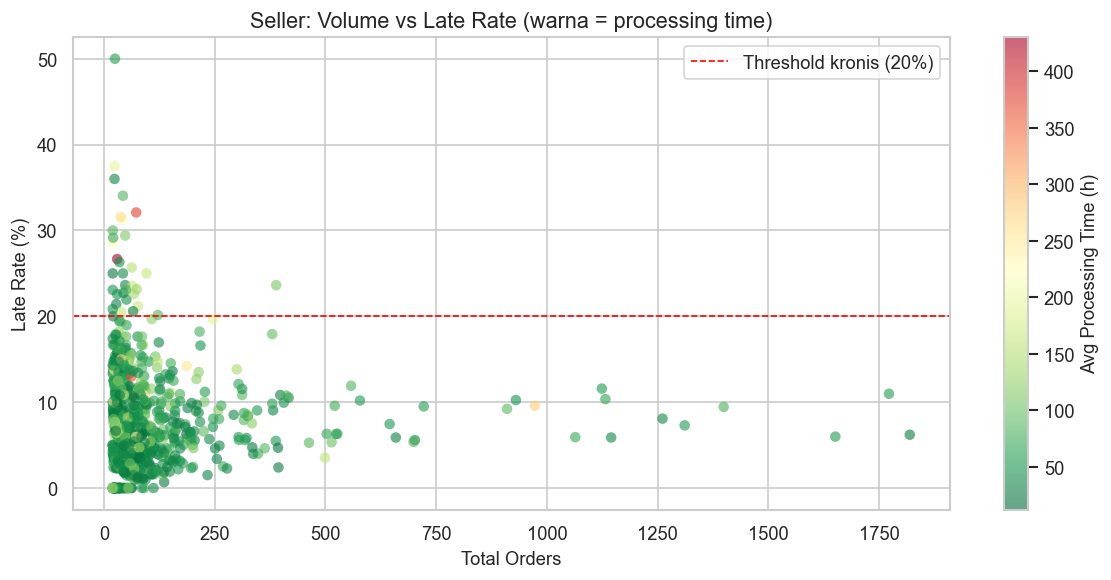

In [169]:
# join dengan items untuk dapat seller_id
del_items = delivered.merge(items[['order_id','seller_id','price','freight_value']], on='order_id')

# agregasi per seller
seller_perf = del_items.groupby('seller_id').agg(
    total_orders = ('order_id', 'nunique'),
    late_rate = ('is_late', 'mean'),
    avg_t2 = ('t2_processing_h', 'mean'),
    avg_delivery = ('delivery_days', 'mean'),
    total_revenue = ('price', 'sum')
).reset_index()

seller_perf['late_pct'] = seller_perf['late_rate'] * 100

# fokus ke seller volume tinggi (>=20 orders)
hv = seller_perf[seller_perf['total_orders'] >= 20].copy()

print(f'Total sellers        : {len(seller_perf):,}')
print(f'High-volume (>=20)   : {len(hv):,}')
print(f'Perfect (0% late)    : {(hv["late_rate"]==0).sum()}')
print(f'Kronis (>20% late)   : {(hv["late_pct"]>20).sum()}')
print()

# scatter: volume vs late rate
fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(hv['total_orders'], hv['late_pct'], c=hv['avg_t2'], cmap='RdYlGn_r', alpha=0.6, s=40, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Avg Processing Time (h)')
ax.axhline(20, color='red', linestyle='--', linewidth=1, label='Threshold kronis (20%)')
ax.set_xlabel('Total Orders')
ax.set_ylabel('Late Rate (%)')
ax.set_title('Seller: Volume vs Late Rate (warna = processing time)')
ax.legend()
plt.tight_layout()
plt.show()


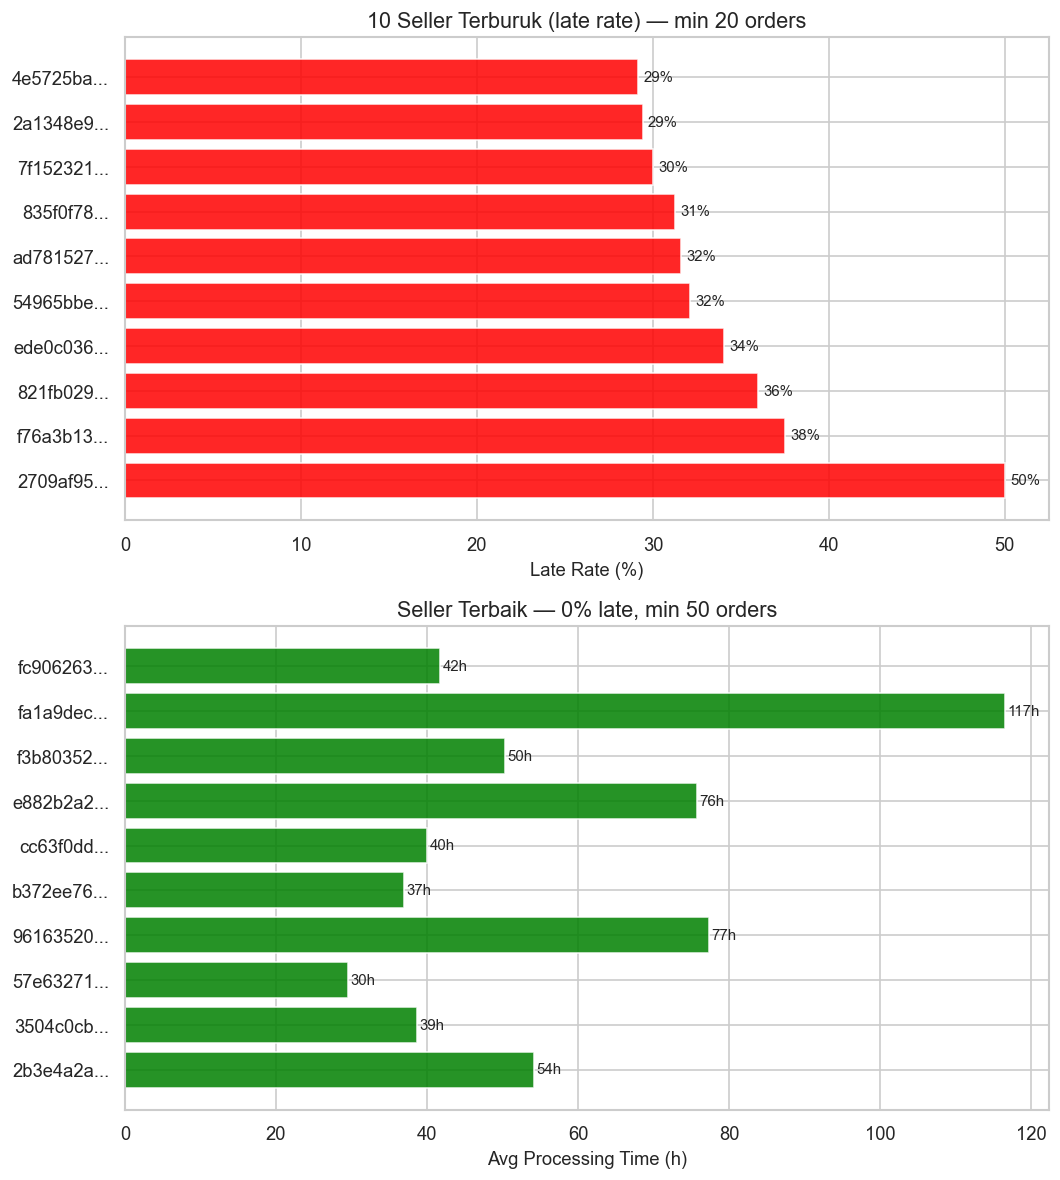

In [170]:
# ranking seller terbaik & terburuk
fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# worst sellers
worst = hv.nlargest(10, 'late_pct')[['seller_id','total_orders','late_pct','avg_t2']]
worst['seller_short'] = worst['seller_id'].str[:8] + '...'
axes[0].barh(worst['seller_short'], worst['late_pct'], color='red', alpha=0.85)
axes[0].set_xlabel('Late Rate (%)')
axes[0].set_title('10 Seller Terburuk (late rate) — min 20 orders')
for i, (_, row) in enumerate(worst.iterrows()):
    axes[0].text(row['late_pct'] + 0.3, i, f'{row["late_pct"]:.0f}%', va='center', fontsize=9)

# best sellers
best = hv[hv['total_orders'] >= 50].nsmallest(10, 'late_pct')[['seller_id','total_orders','late_pct','avg_t2']]
best['seller_short'] = best['seller_id'].str[:8] + '...'
axes[1].barh(best['seller_short'], best['avg_t2'], color='green', alpha=0.85)
axes[1].set_xlabel('Avg Processing Time (h)')
axes[1].set_title('Seller Terbaik — 0% late, min 50 orders')
for i, (_, row) in enumerate(best.iterrows()):
    axes[1].text(row['avg_t2'] + 0.3, i, f'{row["avg_t2"]:.0f}h', va='center', fontsize=9)

plt.tight_layout()
plt.show()


---

### **Regional Analysis**

---

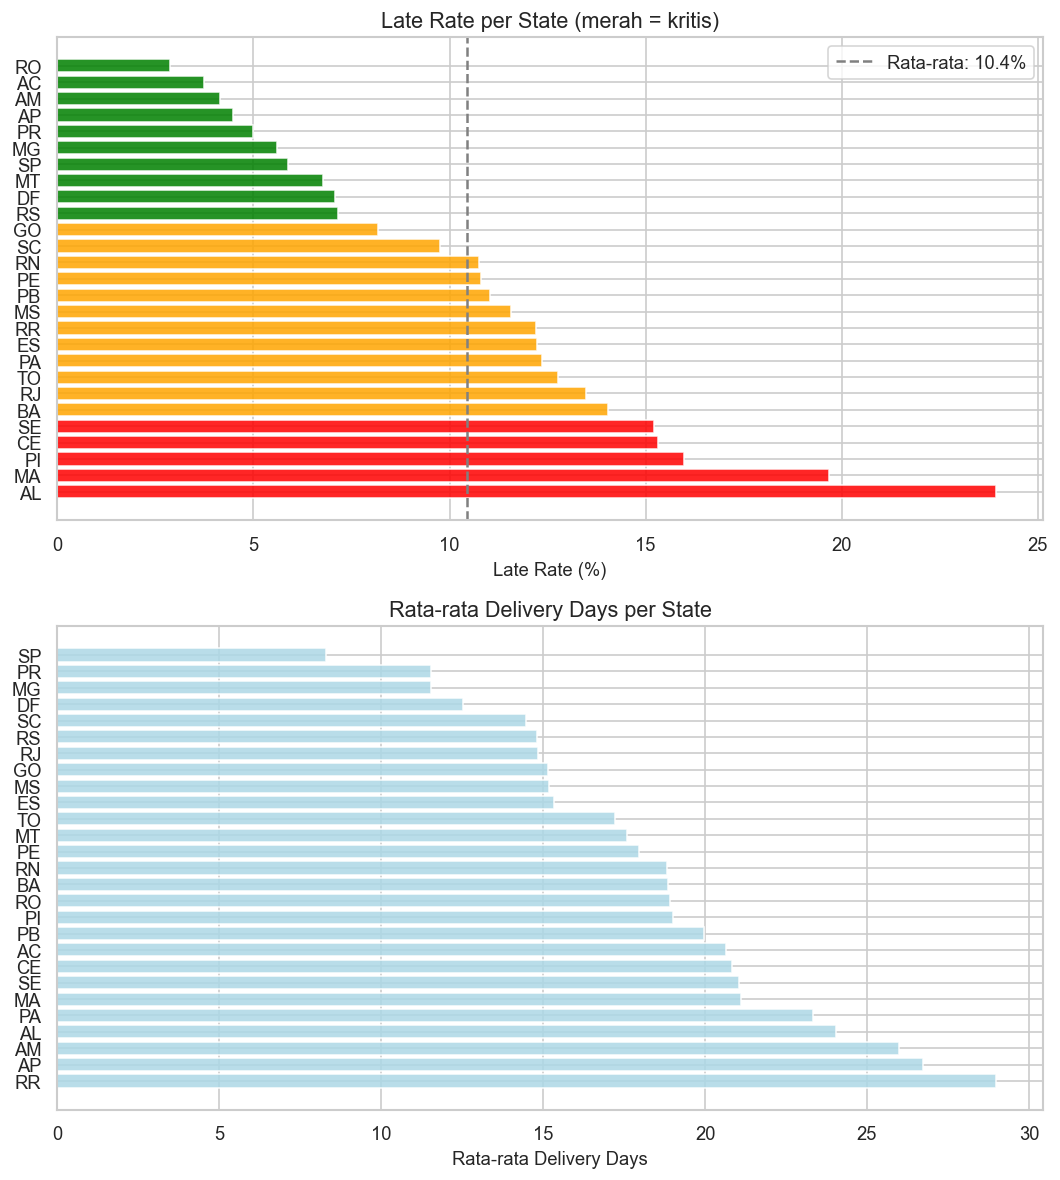

Top 5 worst states:
customer_state  total  late_pct  avg_days
            AL    397 23.929471 24.040302
            MA    717 19.665272 21.117155
            PI    476 15.966387 18.993697
            CE   1279 15.324472 20.817826
            SE    335 15.223881 21.029851

Top 5 best states:
customer_state  total  late_pct  avg_days
            PR   4923  4.996953 11.526711
            AP     67  4.477612 26.731343
            AM    145  4.137931 25.986207
            AC     80  3.750000 20.637500
            RO    243  2.880658 18.913580


In [171]:
# join dengan customers
del_cust = delivered.merge(customers[['customer_id','customer_state']], on='customer_id')

state_stats = del_cust.groupby('customer_state').agg(
    total = ('order_id','count'),
    late_rate = ('is_late','mean'),
    avg_days = ('delivery_days','mean'),
    avg_t3 = ('t3_shipping_h','mean')
).reset_index()
state_stats['late_pct'] = state_stats['late_rate'] * 100
state_stats = state_stats.sort_values('late_pct', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# late rate per state
colors = ['red' if v >= 15 else 'orange' if v >= 8 else 'green'
          for v in state_stats['late_pct']]
axes[0].barh(state_stats['customer_state'], state_stats['late_pct'], color=colors, alpha=0.85)
axes[0].set_xlabel('Late Rate (%)')
axes[0].set_title('Late Rate per State (merah = kritis)')
axes[0].axvline(state_stats['late_pct'].mean(), color='gray', linestyle='--', label=f'Rata-rata: {state_stats["late_pct"].mean():.1f}%')
axes[0].legend()

# avg delivery days per state
state_sorted_days = state_stats.sort_values('avg_days', ascending=False)
axes[1].barh(state_sorted_days['customer_state'], state_sorted_days['avg_days'], color='lightblue', alpha=0.85)
axes[1].set_xlabel('Rata-rata Delivery Days')
axes[1].set_title('Rata-rata Delivery Days per State')

plt.tight_layout()
plt.show()

print('Top 5 worst states:')
print(state_stats.head(5)[['customer_state','total','late_pct','avg_days']].to_string(index=False))
print()
print('Top 5 best states:')
print(state_stats.tail(5)[['customer_state','total','late_pct','avg_days']].to_string(index=False))


---

### **Product Category Analysis**

---

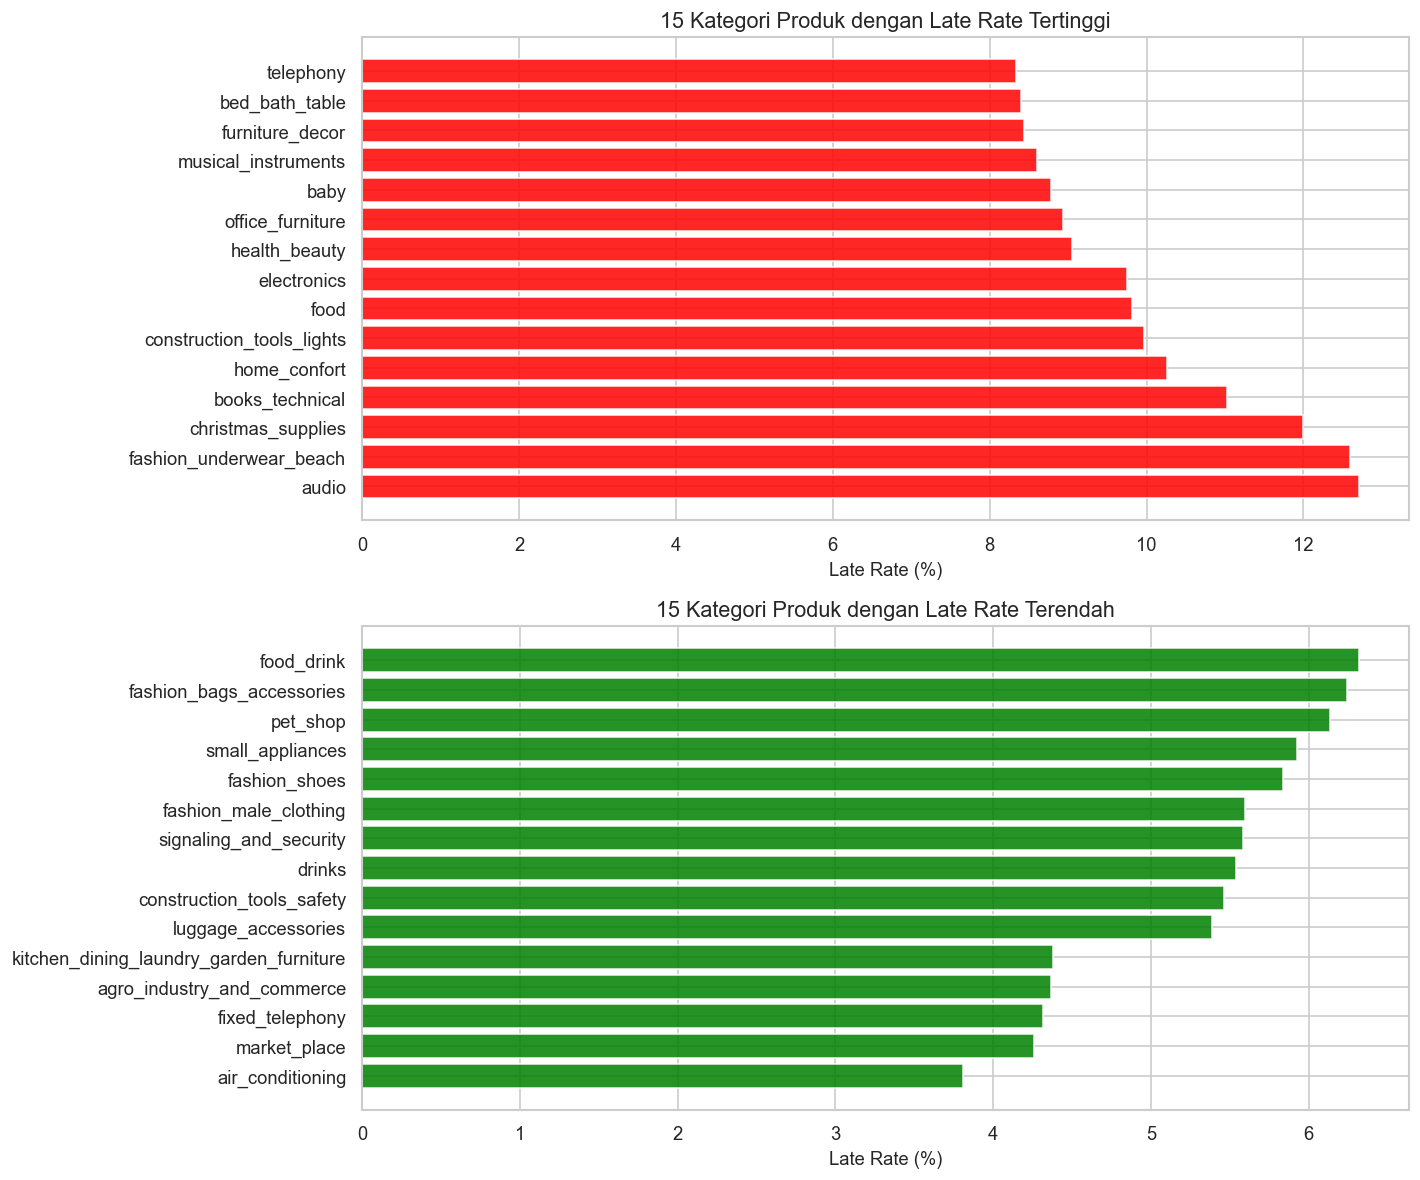

In [172]:
# join produk & kategori
del_items2 = delivered.merge(items[['order_id','product_id']], on='order_id')
del_prod = del_items2.merge(
    products[['product_id','product_category_name']], on='product_id'
)

# join terjemahan
del_prod = del_prod.merge(cat_trans, on='product_category_name', how='left')
del_prod['category_en'] = del_prod['product_category_name_english'].fillna(del_prod['product_category_name'])

cat_stats = del_prod.groupby('category_en').agg(
    total    = ('order_id','nunique'),
    late_rate = ('is_late','mean'),
    avg_days = ('delivery_days','mean')
).reset_index()
cat_stats = cat_stats[cat_stats['total'] >= 100]
cat_stats['late_pct'] = cat_stats['late_rate'] * 100

# plot top/bottom 15
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

top15 = cat_stats.nlargest(15, 'late_pct')
axes[0].barh(top15['category_en'], top15['late_pct'], color='red', alpha=0.85)
axes[0].set_xlabel('Late Rate (%)')
axes[0].set_title('15 Kategori Produk dengan Late Rate Tertinggi')

bot15 = cat_stats.nsmallest(15, 'late_pct')
axes[1].barh(bot15['category_en'], bot15['late_pct'], color='green', alpha=0.85)
axes[1].set_xlabel('Late Rate (%)')
axes[1].set_title('15 Kategori Produk dengan Late Rate Terendah')

plt.tight_layout()
plt.show()


---

### **Cross Analysis — Operasional & Customer Experience**

---

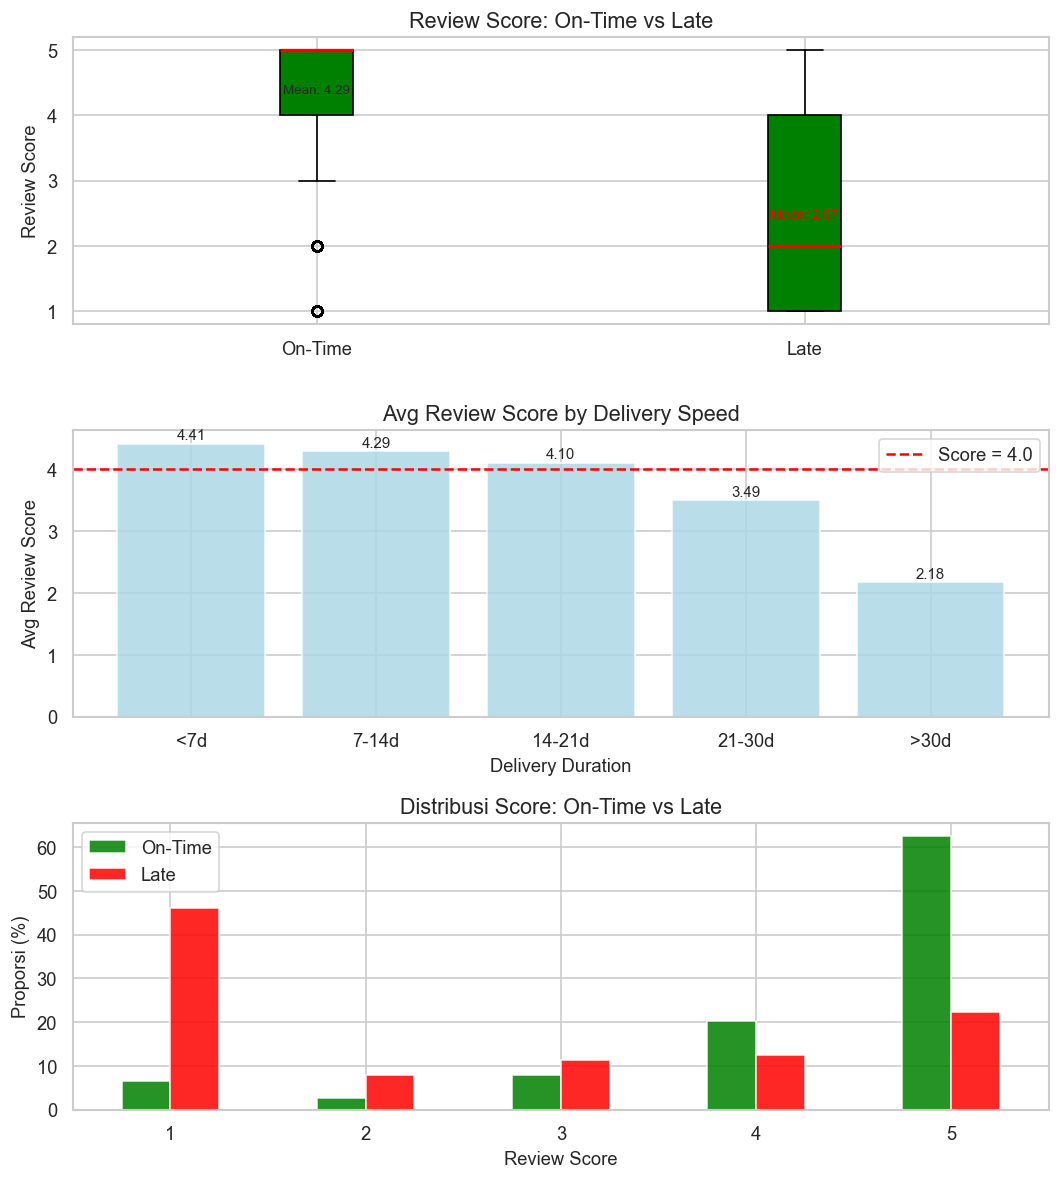

Avg review score on-time : 4.29
Avg review score late    : 2.57
Late orders dapat score 4-5: 2,665 (34.6%)


In [173]:
# join dengan reviews
ops_cx = delivered.merge(
    reviews[['order_id','review_score']], on='order_id', how='left'
)

fig, axes = plt.subplots(3, 1, figsize=(9, 10))

# boxplot review score: late vs ontime
ops_cx_clean = ops_cx.dropna(subset=['review_score'])
late_scores   = ops_cx_clean[ops_cx_clean['is_late'] == True]['review_score']
ontime_scores = ops_cx_clean[ops_cx_clean['is_late'] == False]['review_score']

axes[0].boxplot([ontime_scores, late_scores], labels=['On-Time','Late'], patch_artist=True, boxprops=dict(facecolor='green'), medianprops=dict(color='red', linewidth=2))
axes[0].set_ylabel('Review Score')
axes[0].set_title('Review Score: On-Time vs Late')
axes[0].text(1, ontime_scores.mean() + 0.05, f'Mean: {ontime_scores.mean():.2f}', ha='center', fontsize=8)
axes[0].text(2, late_scores.mean() - 0.15,   f'Mean: {late_scores.mean():.2f}',  ha='center', fontsize=8, color='red')

# review score vs delivery days bucket
ops_cx_clean['delivery_bucket'] = pd.cut(
    ops_cx_clean['delivery_days'],
    bins=[0,7,14,21,30,200],
    labels=['<7d','7-14d','14-21d','21-30d','>30d']
)
bucket_score = ops_cx_clean.groupby('delivery_bucket', observed=True)['review_score'].mean()
axes[1].bar(bucket_score.index, bucket_score.values, color='lightblue', alpha=0.85)
axes[1].set_xlabel('Delivery Duration')
axes[1].set_ylabel('Avg Review Score')
axes[1].set_title('Avg Review Score by Delivery Speed')
axes[1].axhline(4.0, color='red', linestyle='--', label='Score = 4.0')
axes[1].legend()
for i, v in enumerate(bucket_score.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# score distribution: late vs ontime
score_dist = ops_cx_clean.groupby(['is_late','review_score']).size().unstack(fill_value=0)
score_dist_pct = score_dist.div(score_dist.sum(axis=1), axis=0) * 100
score_dist_pct.T.plot(kind='bar', ax=axes[2], color=['green','red'], alpha=0.85)
axes[2].set_xlabel('Review Score')
axes[2].set_ylabel('Proporsi (%)')
axes[2].set_title('Distribusi Score: On-Time vs Late')
axes[2].legend(['On-Time','Late'])
axes[2].set_xticklabels(['1','2','3','4','5'], rotation=0)

plt.tight_layout()
plt.show()

print(f'Avg review score on-time : {ontime_scores.mean():.2f}')
print(f'Avg review score late    : {late_scores.mean():.2f}')
print(f'Late orders dapat score 4-5: {(late_scores >= 4).sum():,} ({(late_scores >= 4).mean()*100:.1f}%)')


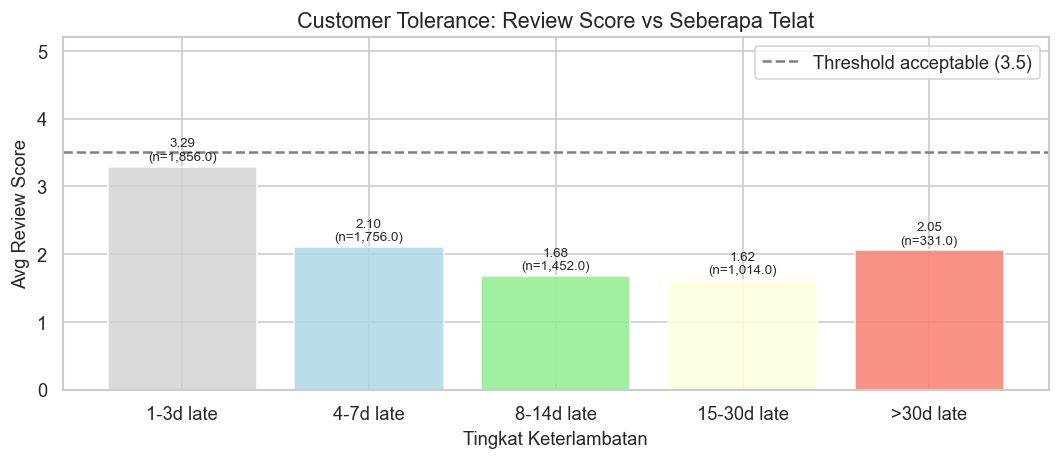

In [174]:
# berapa hari late yang masih bisa ditoleransi customer?
late_orders = ops_cx_clean[ops_cx_clean['is_late'] == True].copy()
late_orders['days_late'] = (
    delivered.set_index('order_id')['days_late'].reindex(late_orders['order_id'].values).values
)

late_bucket = pd.cut(late_orders['days_late'],
                     bins=[0,3,7,14,30,200],
                     labels=['1-3d late','4-7d late','8-14d late','15-30d late','>30d late'])
tolerance = late_orders.groupby(late_bucket, observed=True)['review_score'].agg(['mean','count'])

fig, ax = plt.subplots(figsize=(9, 4))
colors_t = ['lightgray','lightblue','lightgreen','lightyellow','salmon']
bars = ax.bar(tolerance.index, tolerance['mean'], color=colors_t, alpha=0.85)
ax.axhline(3.5, color='gray', linestyle='--', label='Threshold acceptable (3.5)')
ax.set_ylabel('Avg Review Score')
ax.set_xlabel('Tingkat Keterlambatan')
ax.set_title('Customer Tolerance: Review Score vs Seberapa Telat')
ax.set_ylim(0, 5.2)
ax.legend()
for bar, (_, row) in zip(bars, tolerance.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row["mean"]:.2f}\n(n={row["count"]:,})',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


---

### **Correlation Heatmap**

---

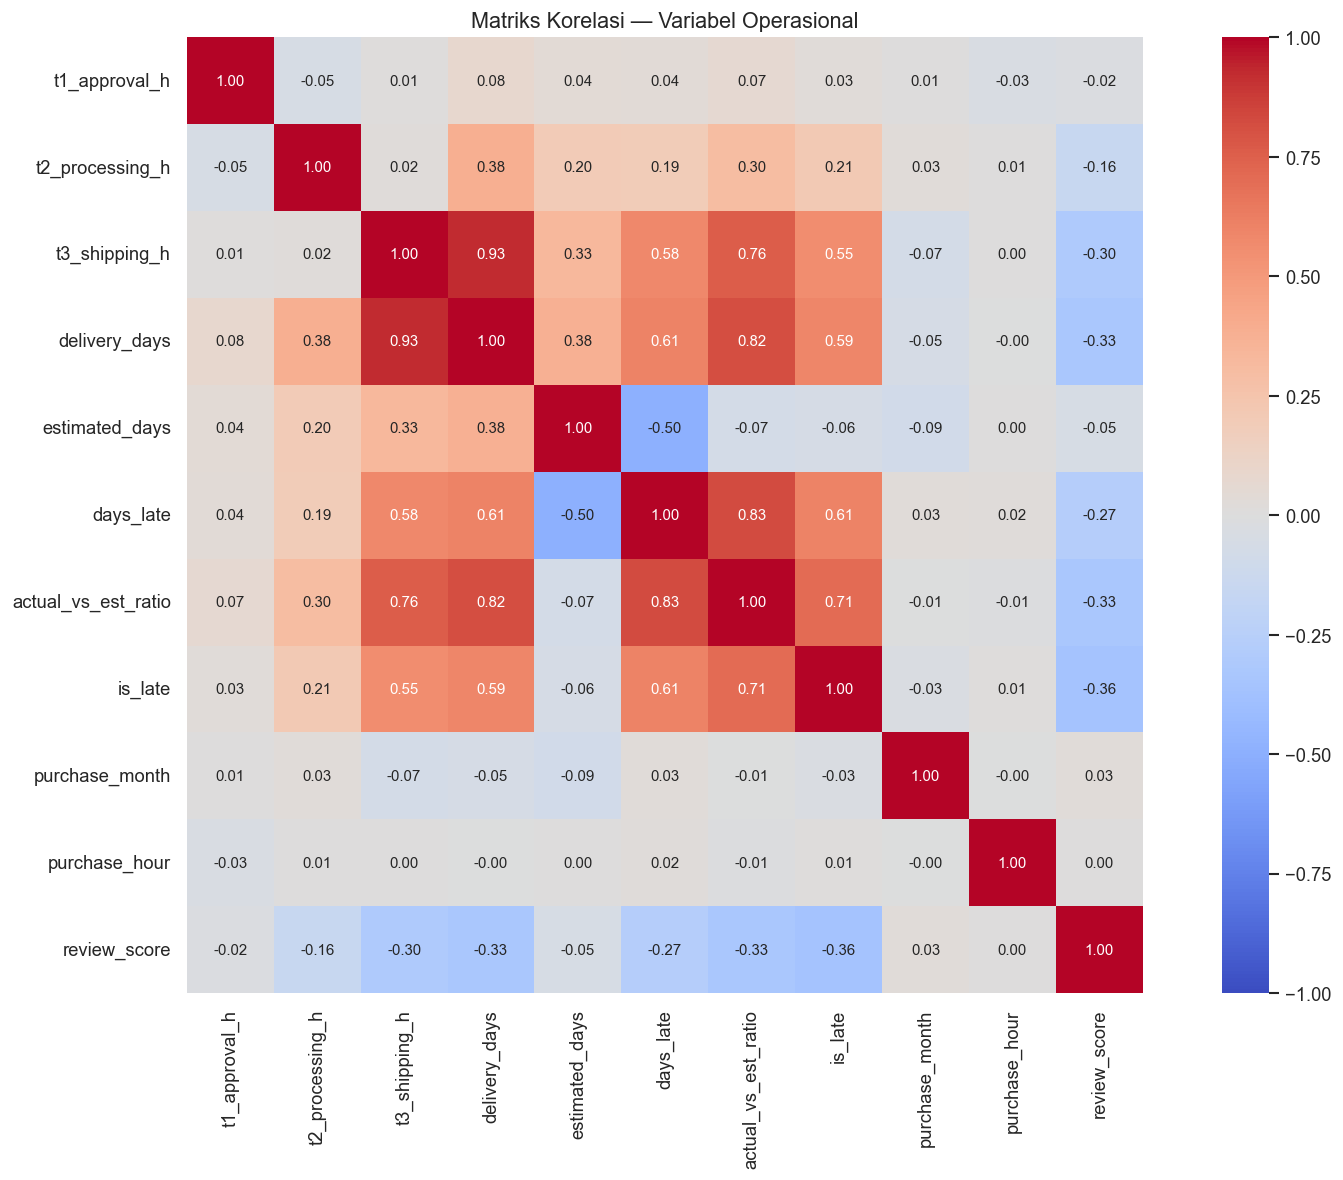

In [175]:
cols = [
    'order_id',
    't1_approval_h',
    't2_processing_h',
    't3_shipping_h',
    'delivery_days',
    'estimated_days',
    'days_late',
    'actual_vs_est_ratio',
    'is_late',
    'purchase_month',
    'purchase_hour'
]

corr_df = delivered[cols].copy()
corr_df = corr_df.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

corr_matrix = corr_df.drop(columns=['order_id']).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={'size': 9}
)
plt.title('Matriks Korelasi — Variabel Operasional')
plt.tight_layout()
plt.show()

---

### **Outlier Analysis**

---

In [176]:
from scipy import stats

cols_outlier = ['delivery_days', 't1_approval_h', 't2_processing_h', 't3_shipping_h']

print('Outlier Analysis — Metode IQR\n')
print(f'{"Kolom":<25} {"Q1":>8} {"Q3":>8} {"IQR":>8} {"Lower":>8} {"Upper":>8} {"Outlier":>8} {"Outlier %":>10}')
print('-' * 90)

outlier_summary = {}
for col in cols_outlier:
    data = delivered[col].dropna()
    data = data[data >= 0]
    
    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower) | (data > upper)]
    outlier_pct = len(outliers) / len(data) * 100
    
    outlier_summary[col] = {
        'count': len(outliers),
        'pct': outlier_pct,
        'upper': upper,
        'max': data.max()
    }
    
    print(f'{col:<25} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} {lower:>8.1f} {upper:>8.1f} {len(outliers):>8,} {outlier_pct:>9.1f}%')

print()
print('Detail outlier ekstrem:')
for col, info in outlier_summary.items():
    print(f'  {col}: max={info["max"]:.1f}, batas normal={info["upper"]:.1f}, outlier={info["count"]:,} ({info["pct"]:.1f}%)')

Outlier Analysis — Metode IQR

Kolom                           Q1       Q3      IQR    Lower    Upper  Outlier  Outlier %
------------------------------------------------------------------------------------------
delivery_days                  6.0     15.0      9.0     -7.5     28.5    5,022       5.2%
t1_approval_h                  0.2     14.5     14.3    -21.2     36.0    8,938       9.3%
t2_processing_h               21.6     86.8     65.2    -76.2    184.7    5,426       5.7%
t3_shipping_h                 98.4    288.7    190.3   -187.0    574.1    5,067       5.3%

Detail outlier ekstrem:
  delivery_days: max=209.0, batas normal=28.5, outlier=5,022 (5.2%)
  t1_approval_h: max=741.4, batas normal=36.0, outlier=8,938 (9.3%)
  t2_processing_h: max=3018.3, batas normal=184.7, outlier=5,426 (5.7%)
  t3_shipping_h: max=4924.6, batas normal=574.1, outlier=5,067 (5.3%)


In [177]:
#  2 order dengan approval delay tertinggi
worst_approval = delivered[delivered['t1_approval_h'] > 700][[
    'order_id',
    'customer_id', 
    'order_purchase_timestamp',
    'order_approved_at',
    't1_approval_h',
    'is_late'
]]

print('Detail 2 order dengan approval delay >700 jam:')
print(worst_approval.to_string(index=False))

# cek seller dari order ini
worst_with_seller = worst_approval.merge(
    items[['order_id','seller_id']], on='order_id'
)
print('\nSeller dari order-order ini:')
print(worst_with_seller[['order_id','seller_id','t1_approval_h']].to_string(index=False))

# cek apakah seller sama atau beda
sellers = worst_with_seller['seller_id'].unique()
print(f'\nJumlah seller unik: {len(sellers)}')
print(f'Seller ID: {sellers}')

Detail 2 order dengan approval delay >700 jam:
                        order_id                      customer_id order_purchase_timestamp   order_approved_at  t1_approval_h  is_late
f7923db0430587601c2aef15ec4b8af4 1318fd61a82a479edaff00217376c052      2018-01-20 17:38:58 2018-02-20 12:05:54     738.448889     True
0a93b40850d3f4becf2f276666e01340 a70076d8d4bfce15f8081951c43bf187      2018-01-20 14:24:50 2018-02-20 11:51:27     741.443611     True

Seller dari order-order ini:
                        order_id                        seller_id  t1_approval_h
f7923db0430587601c2aef15ec4b8af4 f63d8f293af3a6454377546bd9dd19ff     738.448889
f7923db0430587601c2aef15ec4b8af4 f63d8f293af3a6454377546bd9dd19ff     738.448889
f7923db0430587601c2aef15ec4b8af4 f63d8f293af3a6454377546bd9dd19ff     738.448889
f7923db0430587601c2aef15ec4b8af4 f63d8f293af3a6454377546bd9dd19ff     738.448889
0a93b40850d3f4becf2f276666e01340 f8db351d8c4c4c22c6835c19a46f01b0     741.443611

Jumlah seller unik: 2
Seller ID

In [178]:
# order dengan t3_shipping ekstrem
worst_shipping = delivered[delivered['t3_shipping_h'] > 3000][[
    'order_id',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    't3_shipping_h',
    'delivery_days',
    'is_late'
]]

print('Detail order dengan shipping delay >3000 jam (>125 hari):')
print(worst_shipping.to_string(index=False))

# cek seller
worst_ship_seller = worst_shipping.merge(
    items[['order_id','seller_id']], on='order_id'
)
print('\nSeller dari order-order ini:')
print(worst_ship_seller[['order_id','seller_id','t3_shipping_h','delivery_days']].to_string(index=False))

Detail order dengan shipping delay >3000 jam (>125 hari):
                        order_id order_delivered_carrier_date order_delivered_customer_date  t3_shipping_h  delivery_days  is_late
4f39a94d6e474819d898d6df7d394996          2017-05-09 14:06:48           2017-09-19 13:54:18    3191.791667          143.0     True
b31c7dea63bb08f8cdd1ec32514ccf0b          2017-09-29 16:23:06           2018-02-05 21:25:43    3101.043611          132.0     True
47b40429ed8cce3aee9199792275433f          2018-02-06 01:48:28           2018-07-13 20:51:31    3787.050833          191.0     True
c2a550cc5f966506b717532441c221e5          2018-01-15 15:46:55           2018-05-23 20:56:25    3077.158333          131.0     True
cce224811ba8fea016c049693c3e0402          2018-03-02 18:11:39           2018-07-26 16:41:56    3502.504722          148.0     True
7e708aed151d6a8601ce8f2eaa712bf4          2018-06-04 13:42:00           2018-10-17 13:22:46    3239.679444          136.0     True
ca07593549f1816d26a572e06

In [179]:
# cek pola tanggal delivered pada outlier t3
worst_ship = delivered[delivered['t3_shipping_h'] > 3000].copy()

print('Distribusi tanggal delivered customer pada outlier t3:')
date_counts = worst_ship['order_delivered_customer_date'].dt.date.value_counts().head(10)
print(date_counts)

print(f'\nTotal outlier t3 (>3000 jam): {len(worst_ship)}')
print(f'Seller unik: {worst_ship.merge(items[["order_id","seller_id"]], on="order_id")["seller_id"].nunique()}')

Distribusi tanggal delivered customer pada outlier t3:
order_delivered_customer_date
2017-09-19    20
2018-02-05     1
2018-07-13     1
2018-05-23     1
2018-07-26     1
2018-10-17     1
2018-07-23     1
2017-06-14     1
2018-05-10     1
2018-07-20     1
Name: count, dtype: int64

Total outlier t3 (>3000 jam): 40
Seller unik: 39


In [180]:
# order dengan t2_processing ekstrem
worst_processing = delivered[delivered['t2_processing_h'] > 2000].copy()

print('Detail order dengan processing delay >2000 jam (>83 hari):')
print(worst_processing[['order_id','order_approved_at','order_delivered_carrier_date','t2_processing_h','is_late']].to_string(index=False))

# cek seller
worst_proc_seller = worst_processing.merge(
    items[['order_id','seller_id']], on='order_id'
)
print('\nSeller dari order-order ini:')
print(worst_proc_seller[['order_id','seller_id','t2_processing_h']].to_string(index=False))

# cek apakah seller sama atau beda
print(f'\nTotal order: {len(worst_processing)}')
print(f'Seller unik: {worst_proc_seller["seller_id"].nunique()}')

# cek pola tanggal carrier
print('\nDistribusi tanggal ke carrier:')
print(worst_processing['order_delivered_carrier_date'].dt.date.value_counts().head(10))

Detail order dengan processing delay >2000 jam (>83 hari):
                        order_id   order_approved_at order_delivered_carrier_date  t2_processing_h  is_late
8b7fd198ad184563c231653673e75a7f 2017-11-17 08:47:00          2018-02-26 17:27:15      2432.670833     True
97f48024fcc76f1898e397ad6966e3a0 2017-11-29 12:41:24          2018-03-16 13:58:02      2569.277222     True
da81fbc27b55e0f3d2813cf2078dc780 2017-11-14 21:26:34          2018-03-20 15:44:40      3018.301667     True

Seller dari order-order ini:
                        order_id                        seller_id  t2_processing_h
8b7fd198ad184563c231653673e75a7f e09887ca8c7bf8a4621ce481820414ef      2432.670833
97f48024fcc76f1898e397ad6966e3a0 9b522ba7eae9e1d04082f267144583cc      2569.277222
da81fbc27b55e0f3d2813cf2078dc780 5d378b73ab7dd6f0418d743e5dcb0bd1      3018.301667

Total order: 3
Seller unik: 3

Distribusi tanggal ke carrier:
order_delivered_carrier_date
2018-02-26    1
2018-03-16    1
2018-03-20    1
Name: c

| Kolom | Temuan | Keputusan | Alasan |
|---|---|---|---|
| t1_approval_h | 2 order butuh 741 jam untuk diapprove | Dikeluarkan | 2 seller berbeda tapi diapprove di hari yang sama persis dengan selisih 14 menit, dianggap error sistem, bukan kejadian normal |
| t3_shipping_h | 40 order butuh >125 hari di kurir | Dikeluarkan | 20 dari 40 order arrived di tanggal yang sama persis (19 Sep 2017) dari 39 seller berbeda, dianggap batch update sistem, bukan tanggal realita barang sampai |
| t2_processing_h | 3 order butuh >83 hari seller proses barang | Dipertahankan | Seller berbeda, tanggal berbeda, tidak ada pola mencurigakan, dianggap memang seller yang sangat lambat, bukan error sistem |
| delivery_days | 40 order butuh >130 hari total | Dikeluarkan | Sama dengan t3, outlier nya karena error sistem yang sama |


---

### **Cohort Analysis Seller**

---

In [181]:
# gabungkan delivered dengan items untuk dapat seller_id
del_items_cohort = delivered.merge(
    items[['order_id', 'seller_id']], on='order_id'
)

# cari kapan pertama kali setiap seller punya order
seller_first_order = del_items_cohort.groupby('seller_id')['order_purchase_timestamp'].min().reset_index()
seller_first_order.columns = ['seller_id', 'first_order_date']

# buat label cohort berdasarkan kuartal
seller_first_order['cohort'] = seller_first_order['first_order_date'].dt.to_period('Q').astype(str)

# gabungkan ke data utama
del_items_cohort = del_items_cohort.merge(seller_first_order, on='seller_id')

print('Jumlah seller per cohort:')
cohort_counts = seller_first_order['cohort'].value_counts().sort_index()
print(cohort_counts)

Jumlah seller per cohort:
cohort
2016Q3      1
2016Q4    128
2017Q1    524
2017Q2    295
2017Q3    357
2017Q4    410
2018Q1    363
2018Q2    556
2018Q3    336
Name: count, dtype: int64


In [182]:
# hitung performa per cohort
cohort_perf = del_items_cohort.groupby('cohort').agg(
    total_orders  = ('order_id', 'nunique'),
    late_orders   = ('is_late', 'sum'),
    late_rate     = ('is_late', 'mean'),
    seller_count  = ('seller_id', 'nunique')
).reset_index()
cohort_perf['late_pct'] = cohort_perf['late_rate'] * 100
cohort_perf = cohort_perf.sort_values('cohort')

print('Performa per cohort seller:')
print(cohort_perf[['cohort','seller_count','total_orders','late_pct']].to_string(index=False))

Performa per cohort seller:
cohort  seller_count  total_orders  late_pct
2016Q3             1            12 25.000000
2016Q4           128         10699  6.971696
2017Q1           524         36476  7.283878
2017Q2           295         11253  7.818548
2017Q3           357         14252  8.489244
2017Q4           410         11551  9.558993
2018Q1           363          6747  9.824008
2018Q2           556          5252  6.600605
2018Q3           336          1258  7.769784


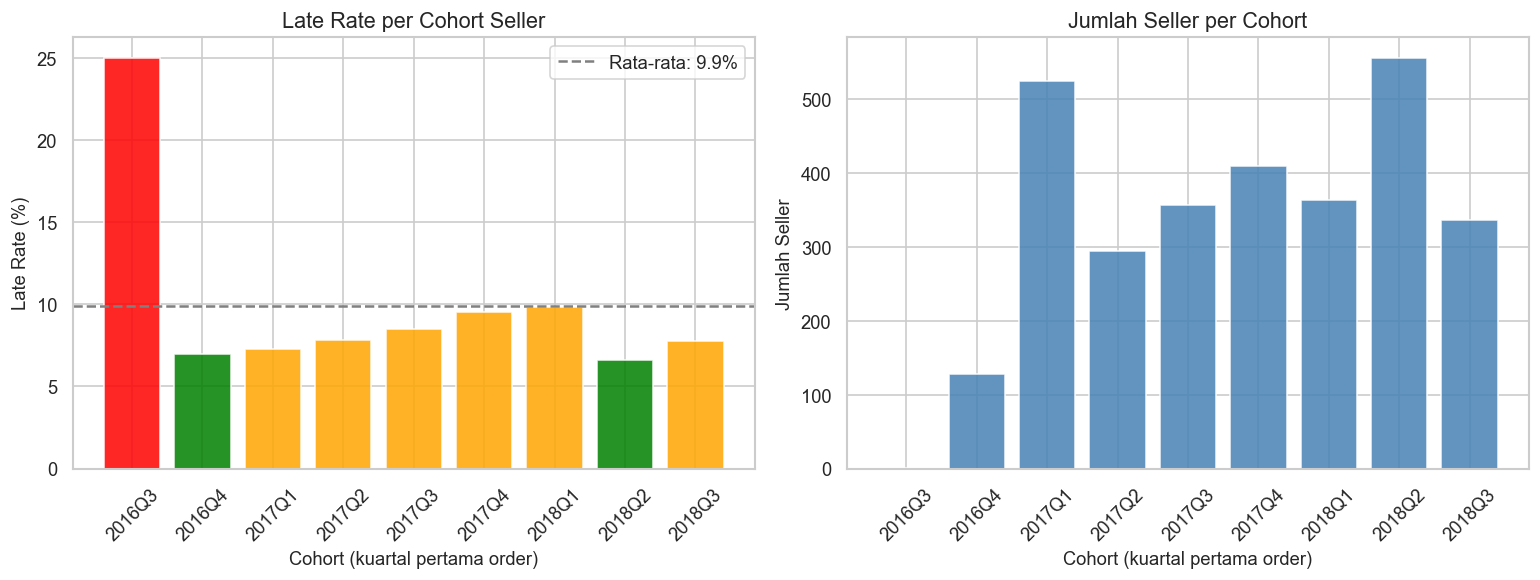

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# late rate per cohort
colors = ['red' if v >= 10 else 'orange' if v >= 7 else 'green' 
          for v in cohort_perf['late_pct']]
axes[0].bar(cohort_perf['cohort'], cohort_perf['late_pct'], color=colors, alpha=0.85)
axes[0].axhline(cohort_perf['late_pct'].mean(), color='gray', linestyle='--', label=f'Rata-rata: {cohort_perf["late_pct"].mean():.1f}%')
axes[0].set_xlabel('Cohort (kuartal pertama order)')
axes[0].set_ylabel('Late Rate (%)')
axes[0].set_title('Late Rate per Cohort Seller')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# jumlah seller per cohort
axes[1].bar(cohort_perf['cohort'], cohort_perf['seller_count'], color='steelblue', alpha=0.85)
axes[1].set_xlabel('Cohort (kuartal pertama order)')
axes[1].set_ylabel('Jumlah Seller')
axes[1].set_title('Jumlah Seller per Cohort')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- Seller yang masuk di **2016Q4 dan 2017Q1** punya late rate terendah (7%), seller lama yang sudah terbiasa dengan sistem
- Seller yang masuk di **2017Q3 sampai 2018Q1** punya late rate paling tinggi (8.5-9.8%), periode platform tumbuh pesat, kemungkinan standar seleksi seller lebih longgar/ada suatu event tahunan
- Seller yang masuk di **2018Q2** tiba-tiba membaik (6.6%), kemungkinan platform mulai lebih selektif/event tahunan sudah selesai

jadi seller lama tidak otomatis lebih baik. Yang bermasalah justru seller dari masa pertumbuhan pesat. Solusinya selain memperingatkan seller lama, tapi perketat seleksi seller baru dari awal.

---

### **Freight Value Analysis**

---

ongkir yang lebih mahal menjamin pengiriman lebih tepat waktu atau tidak?

In [184]:
# distribusi freight value

# gabungkan dengan items untuk dapat freight_value
del_freight = delivered.merge(
    items[['order_id','freight_value','price']], on='order_id'
)

# agregasi per order (kalau multi-item)
order_freight = del_freight.groupby('order_id').agg(
    total_freight = ('freight_value','sum'),
    total_price   = ('price','sum'),
    is_late       = ('is_late','first')
).reset_index()

# freight ratio = ongkir / harga barang
order_freight['freight_ratio'] = order_freight['total_freight'] / order_freight['total_price']

print('Statistik freight value:')
print(order_freight['total_freight'].describe().round(2))
print(f'\nRata-rata ongkir    : R$ {order_freight["total_freight"].mean():.2f}')
print(f'Rata-rata harga     : R$ {order_freight["total_price"].mean():.2f}')
print(f'Rata-rata rasio     : {order_freight["freight_ratio"].mean():.2%}')

Statistik freight value:
count    96478.00
mean        22.79
std         21.56
min          0.00
25%         13.85
50%         17.17
75%         24.02
max       1794.96
Name: total_freight, dtype: float64

Rata-rata ongkir    : R$ 22.79
Rata-rata harga     : R$ 137.04
Rata-rata rasio     : 30.84%


In [185]:
# korelasi freight vs keterlambatan

# bagi freight jadi bucket
order_freight['freight_bucket'] = pd.qcut(
    order_freight['total_freight'],
    q=5,
    labels=['Sangat murah','Murah','Sedang','Mahal','Sangat mahal']
)

freight_perf = order_freight.groupby('freight_bucket', observed=True).agg(
    total_orders = ('order_id','count'),
    late_rate    = ('is_late','mean'),
    avg_freight  = ('total_freight','mean')
).reset_index()
freight_perf['late_pct'] = freight_perf['late_rate'] * 100

print('Late rate per kategori ongkir:')
print(freight_perf[['freight_bucket','total_orders','avg_freight','late_pct']].to_string(index=False))

Late rate per kategori ongkir:
freight_bucket  total_orders  avg_freight  late_pct
  Sangat murah         19399     9.745536  6.077633
         Murah         19194    14.475433  7.236636
        Sedang         19381    17.187387  8.859192
         Mahal         19228    22.232113  9.044102
  Sangat mahal         19276    50.362768  9.348413


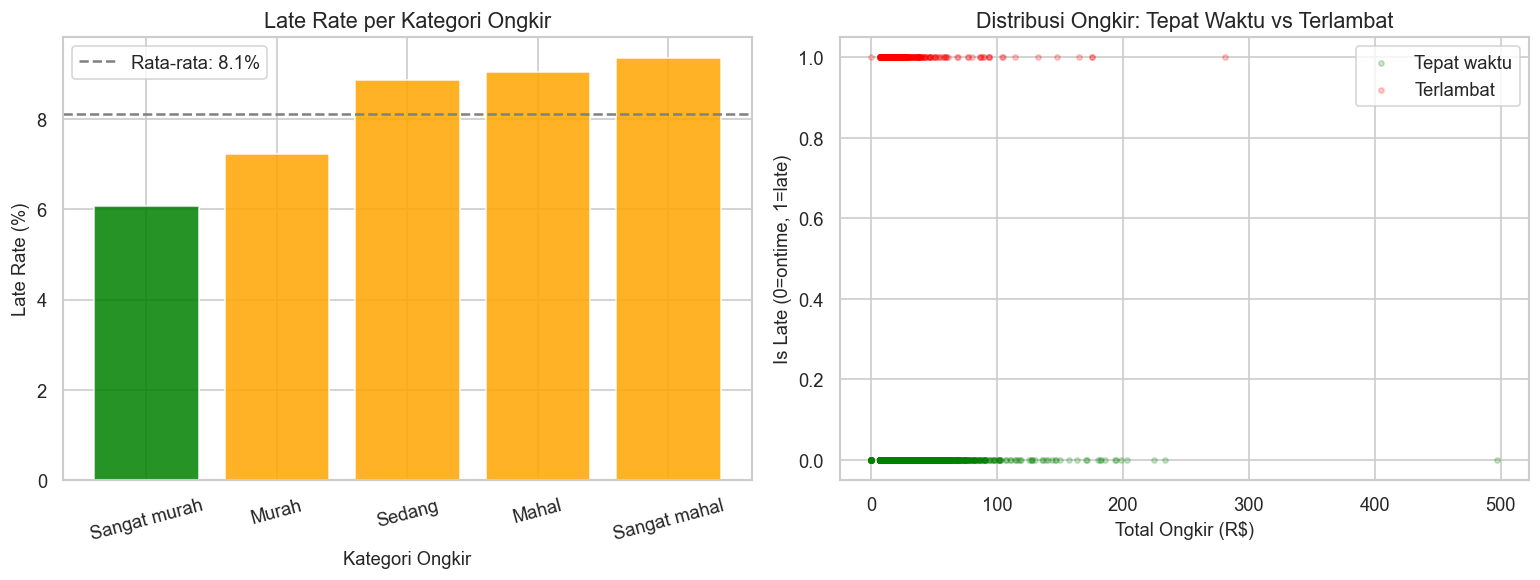

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# late rate per freight bucket
colors = ['red' if v >= 10 else 'orange' if v >= 7 else 'green'
          for v in freight_perf['late_pct']]
axes[0].bar(freight_perf['freight_bucket'], freight_perf['late_pct'], color=colors, alpha=0.85)
axes[0].set_xlabel('Kategori Ongkir')
axes[0].set_ylabel('Late Rate (%)')
axes[0].set_title('Late Rate per Kategori Ongkir')
axes[0].axhline(freight_perf['late_pct'].mean(), color='gray', linestyle='--', label=f'Rata-rata: {freight_perf["late_pct"].mean():.1f}%')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# scatter freight vs late rate per order
sample = order_freight.sample(5000, random_state=42)
late_sample   = sample[sample['is_late'] == True]
ontime_sample = sample[sample['is_late'] == False]

axes[1].scatter(ontime_sample['total_freight'], ontime_sample['is_late'], alpha=0.2, color='green', s=10, label='Tepat waktu')
axes[1].scatter(late_sample['total_freight'], late_sample['is_late'], alpha=0.2, color='red', s=10, label='Terlambat')
axes[1].set_xlabel('Total Ongkir (R$)')
axes[1].set_ylabel('Is Late (0=ontime, 1=late)')
axes[1].set_title('Distribusi Ongkir: Tepat Waktu vs Terlambat')
axes[1].legend()

plt.tight_layout()
plt.show()

- Ongkir paling murah late rate **6.1%**, ongkir paling mahal justru **9.3%**
- Bukan berarti kurir mahal lebih buruk tapi ongkir mahal biasanya untuk wilayah jauh (Nordeste) dan produk berat (audio, elektronik) yang memang lebih rawan telat
- Rata-rata ongkir R$ 22.79 dari total harga barang R$ 137 rasio 30.84%

jadi ongkir tidak bisa dijadikan ukuran kualitas pengiriman. Perusahaan perlu standar SLA yang terpisah dari harga ongkir, terutama untuk wilayah terpencil dan produk berat.

---

### **Peak Time & Special Event Analysis**

---

November punya late rate tinggi (14.3%)

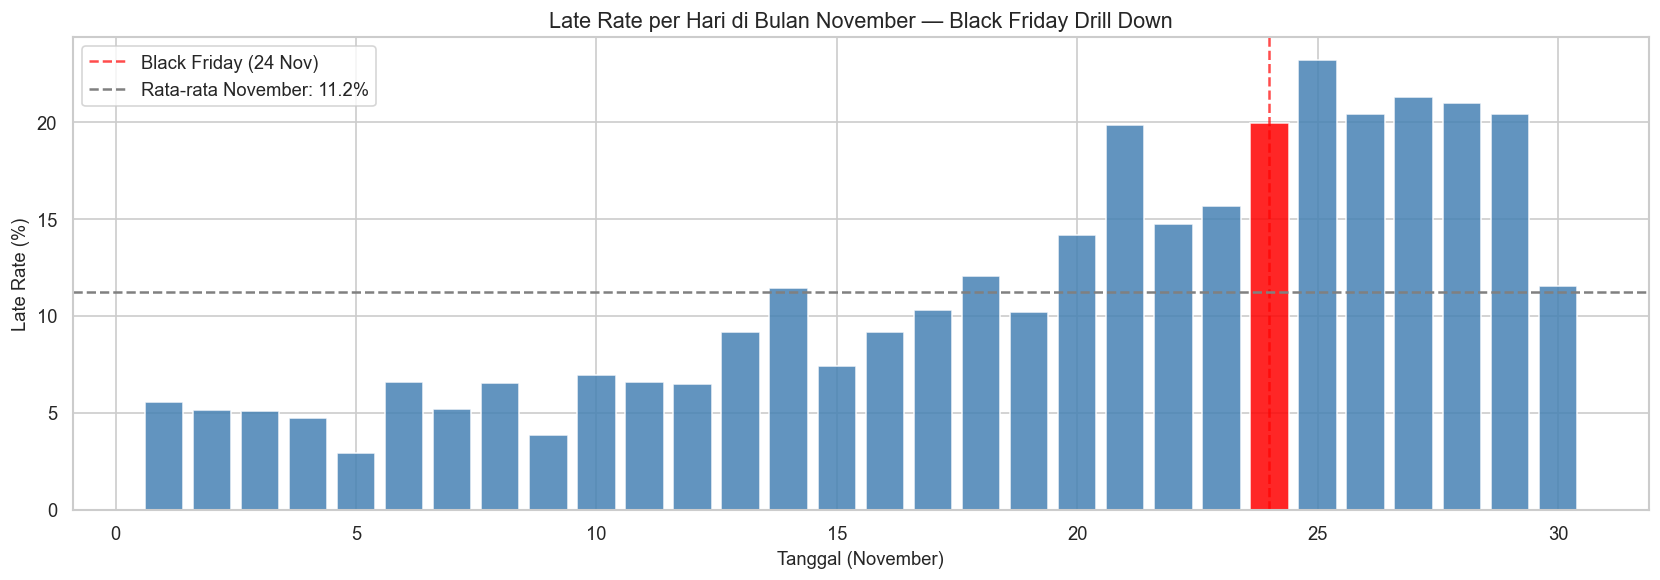


Late rate di hari Black Friday (24 Nov): 20.0%
Rata-rata late rate November: 11.2%
Rata-rata late rate keseluruhan: 8.1%


In [187]:
# black friday 2017: 24 November 2017
# black friday 2018: 23 November 2018

delivered['order_date'] = delivered['order_purchase_timestamp'].dt.date
delivered['order_date'] = pd.to_datetime(delivered['order_date'])

# fokus ke November saja
nov_orders = delivered[delivered['purchase_month'] == 11].copy()
nov_orders['day'] = nov_orders['order_purchase_timestamp'].dt.day

# late rate per hari di November
nov_daily = nov_orders.groupby('day').agg(
    total_orders = ('order_id', 'count'),
    late_orders = ('is_late', 'sum'),
    late_rate = ('is_late', 'mean')
).reset_index()
nov_daily['late_pct'] = nov_daily['late_rate'] * 100

# plot
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(nov_daily['day'], nov_daily['late_pct'], color=['red' if d == 24 else 'steelblue' for d in nov_daily['day']], alpha=0.85)
ax.axvline(x=24, color='red', linestyle='--', alpha=0.7, label='Black Friday (24 Nov)')
ax.axhline(y=nov_daily['late_pct'].mean(), color='gray', linestyle='--', label=f'Rata-rata November: {nov_daily["late_pct"].mean():.1f}%')
ax.set_xlabel('Tanggal (November)')
ax.set_ylabel('Late Rate (%)')
ax.set_title('Late Rate per Hari di Bulan November — Black Friday Drill Down')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nLate rate di hari Black Friday (24 Nov): {nov_daily[nov_daily['day']==24]['late_pct'].values[0]:.1f}%")
print(f"Rata-rata late rate November: {nov_daily['late_pct'].mean():.1f}%")
print(f"Rata-rata late rate keseluruhan: {delivered['is_late'].mean()*100:.1f}%")

tanggal 25-27 November justru lebih tinggi sampai 22%

masalahnya bukan di hari Black Friday, tapi **efek domino setelahnya** jadi sistem kewalahan memproses lonjakan order dan baru terasa dampaknya beberapa hari kedepan

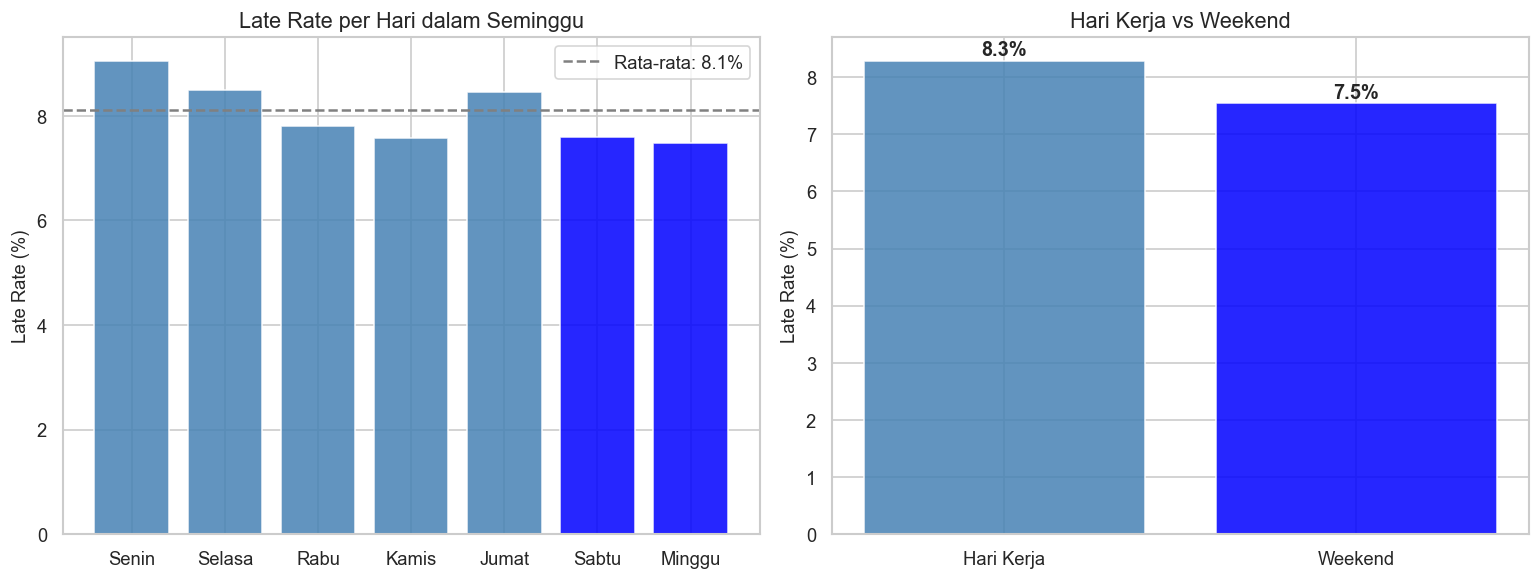


Summary:
  Hari Kerja: 8.3% late rate (74,288 orders)
  Weekend: 7.5% late rate (22,190 orders)


In [188]:
# workdays vs weekend analysis
day_names = {0:'Senin', 1:'Selasa', 2:'Rabu', 3:'Kamis', 4:'Jumat', 5:'Sabtu', 6:'Minggu'}

delivered['day_name'] = delivered['purchase_dayofweek'].map(day_names)
delivered['is_weekend'] = delivered['purchase_dayofweek'].isin([5, 6]).astype(int)

# late rate per hari
daily_perf = delivered.groupby(['purchase_dayofweek', 'day_name']).agg(
    total_orders = ('order_id', 'count'),
    late_rate    = ('is_late', 'mean')
).reset_index()
daily_perf['late_pct'] = daily_perf['late_rate'] * 100
daily_perf = daily_perf.sort_values('purchase_dayofweek')

# workday vs weekend summary
wd_summary = delivered.groupby('is_weekend').agg(
    total_orders = ('order_id', 'count'),
    late_rate    = ('is_late', 'mean')
).reset_index()
wd_summary['kategori'] = wd_summary['is_weekend'].map({0:'Hari Kerja', 1:'Weekend'})
wd_summary['late_pct'] = wd_summary['late_rate'] * 100

# plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# per hari
colors = ['blue' if d >= 5 else 'steelblue' for d in daily_perf['purchase_dayofweek']]
axes[0].bar(daily_perf['day_name'], daily_perf['late_pct'], color=colors, alpha=0.85)
axes[0].axhline(delivered['is_late'].mean()*100, color='gray', linestyle='--', label=f'Rata-rata: {delivered["is_late"].mean()*100:.1f}%')
axes[0].set_title('Late Rate per Hari dalam Seminggu')
axes[0].set_ylabel('Late Rate (%)')
axes[0].legend()

# workday vs weekend
axes[1].bar(wd_summary['kategori'], wd_summary['late_pct'], color=['steelblue', 'blue'], alpha=0.85)
axes[1].set_title('Hari Kerja vs Weekend')
axes[1].set_ylabel('Late Rate (%)')
for i, v in enumerate(wd_summary['late_pct']):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nSummary:')
for _, row in wd_summary.iterrows():
    print(f"  {row['kategori']}: {row['late_pct']:.1f}% late rate ({row['total_orders']:,} orders)")

keterlambatan lebih dipengaruhi oleh **volume order** daripada hari pembelian

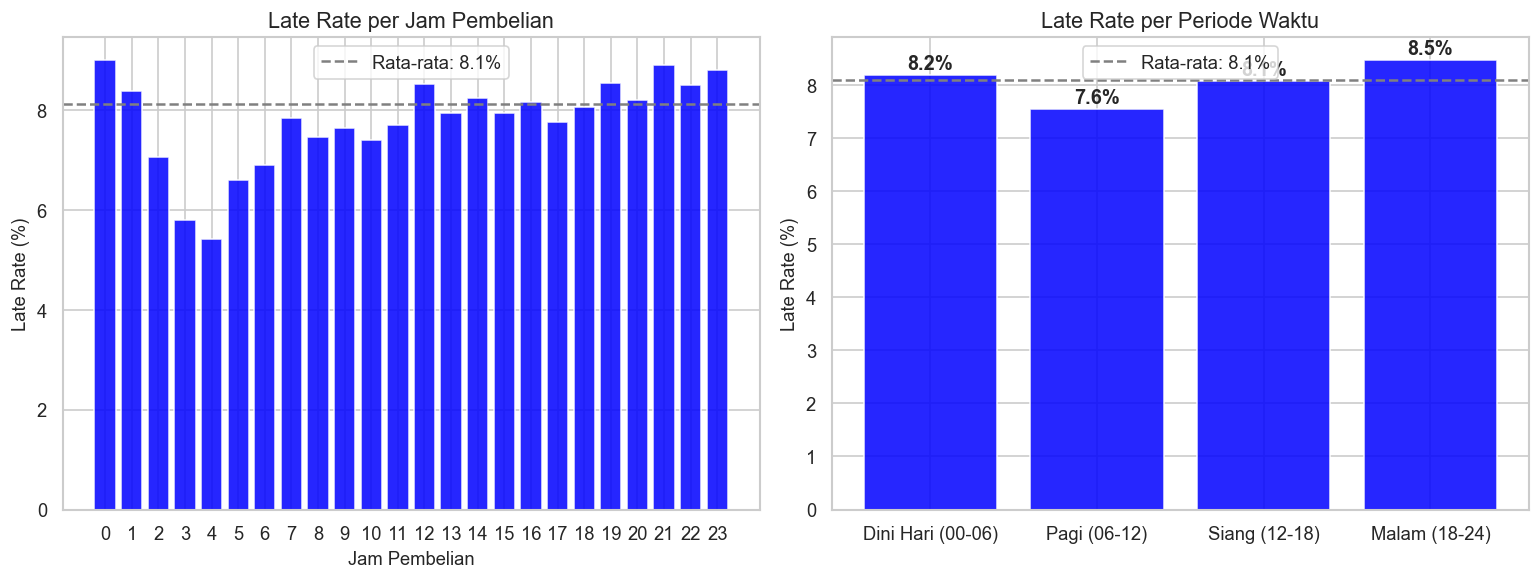


Summary per periode:
  Dini Hari (00-06): 8.2% (4,594 orders)
  Pagi (06-12): 7.6% (21,594 orders)
  Siang (12-18): 8.1% (37,183 orders)
  Malam (18-24): 8.5% (33,107 orders)


In [189]:
# time of day analysis
def get_time_period(hour):
    if 6 <= hour < 12:
        return 'Pagi (06-12)'
    elif 12 <= hour < 18:
        return 'Siang (12-18)'
    elif 18 <= hour < 24:
        return 'Malam (18-24)'
    else:
        return 'Dini Hari (00-06)'

delivered['time_period'] = delivered['purchase_hour'].apply(get_time_period)

# late rate per jam
hourly_perf = delivered.groupby('purchase_hour').agg(
    total_orders = ('order_id', 'count'),
    late_rate    = ('is_late', 'mean')
).reset_index()
hourly_perf['late_pct'] = hourly_perf['late_rate'] * 100

# late rate per periode
period_order = ['Dini Hari (00-06)', 'Pagi (06-12)', 'Siang (12-18)', 'Malam (18-24)']
period_perf = delivered.groupby('time_period').agg(
    total_orders = ('order_id', 'count'),
    late_rate    = ('is_late', 'mean')
).reset_index()
period_perf['late_pct'] = period_perf['late_rate'] * 100
period_perf['time_period'] = pd.Categorical(period_perf['time_period'], categories=period_order, ordered=True)
period_perf = period_perf.sort_values('time_period')

# plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# per jam
axes[0].bar(hourly_perf['purchase_hour'], hourly_perf['late_pct'], color='blue', alpha=0.85)
axes[0].axhline(delivered['is_late'].mean()*100, color='gray', linestyle='--', label=f'Rata-rata: {delivered["is_late"].mean()*100:.1f}%')
axes[0].set_xlabel('Jam Pembelian')
axes[0].set_ylabel('Late Rate (%)')
axes[0].set_title('Late Rate per Jam Pembelian')
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# per periode
axes[1].bar(period_perf['time_period'], period_perf['late_pct'], color='blue', alpha=0.85)
axes[1].axhline(delivered['is_late'].mean()*100, color='gray', linestyle='--', label=f'Rata-rata: {delivered["is_late"].mean()*100:.1f}%')
axes[1].set_title('Late Rate per Periode Waktu')
axes[1].set_ylabel('Late Rate (%)')
axes[1].legend()
for i, v in enumerate(period_perf['late_pct']):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nSummary per periode:')
for _, row in period_perf.iterrows():
    print(f"  {row['time_period']}: {row['late_pct']:.1f}% ({row['total_orders']:,} orders)")

order pagi diproses seller di hari yang sama sehingga lebih cepat masuk ke kurir

order malam baru bisa diproses seller keesokan harinya, menambah waktu processing


---

### **Statistical Significance Testing**

---

sebenarnya apakah perbedaan itu memang benar seperti itu, atau hanya kebetulan karena sample-nya kecil?
 
jadi untuk testing mencoba menggunakan chi-square test, dan hasilnya akan berupa p-value:
- p-value < 0.05 = perbedaannya memang benar, bukan kebetulan
- p-value > 0.05 = perbedaannya bisa jadi hanya kebetulan

In [190]:
# late rate AL vs SP
from scipy.stats import chi2_contingency

# ambil data AL dan SP
del_cust = delivered.merge(customers[['customer_id','customer_state']], on='customer_id')
al = del_cust[del_cust['customer_state'] == 'AL']['is_late']
sp = del_cust[del_cust['customer_state'] == 'SP']['is_late']

# buat contingency table
tabel_1 = [
    [int((~al.astype(bool)).sum()), int(al.sum())],  # AL tepat waktu, terlambat
    [int((~sp.astype(bool)).sum()), int(sp.sum())]   # SP tepat waktu, terlambat
]

chi2, p, dof, expected = chi2_contingency(tabel_1)

print('Uji 1 — Late rate AL vs SP')
print(f'   AL: {al.sum()} terlambat dari {len(al)} order ({al.mean()*100:.1f}%)')
print(f'   SP: {sp.sum()} terlambat dari {len(sp)} order ({sp.mean()*100:.1f}%)')
print(f'   Chi-square : {chi2:.2f}')
print(f'   P-value    : {p:.6f}')
print(f'   Kesimpulan : {"Signifikan — perbedaan bukan kebetulan" if p < 0.05 else "Tidak signifikan"}')

Uji 1 — Late rate AL vs SP
   AL: 95 terlambat dari 397 order (23.9%)
   SP: 2387 terlambat dari 40501 order (5.9%)
   Chi-square : 221.19
   P-value    : 0.000000
   Kesimpulan : Signifikan — perbedaan bukan kebetulan


In [191]:
# late rate maret vs juni
maret = delivered[delivered['purchase_month'] == 3]['is_late']
juni  = delivered[delivered['purchase_month'] == 6]['is_late']

tabel_2 = [
    [int((~maret.astype(bool)).sum()), int(maret.sum())],
    [int((~juni.astype(bool)).sum()),  int(juni.sum())]
]

chi2, p, dof, expected = chi2_contingency(tabel_2)

print('Uji 2 — Late rate Maret vs Juni')
print(f'   Maret: {maret.sum()} terlambat dari {len(maret)} order ({maret.mean()*100:.1f}%)')
print(f'   Juni : {juni.sum()} terlambat dari {len(juni)} order ({juni.mean()*100:.1f}%)')
print(f'   Chi-square : {chi2:.2f}')
print(f'   P-value    : {p:.6f}')
print(f'   Kesimpulan : {"Signifikan — perbedaan bukan kebetulan" if p < 0.05 else "Tidak signifikan"}')

Uji 2 — Late rate Maret vs Juni
   Maret: 1638 terlambat dari 9549 order (17.2%)
   Juni : 204 terlambat dari 9234 order (2.2%)
   Chi-square : 1183.65
   P-value    : 0.000000
   Kesimpulan : Signifikan — perbedaan bukan kebetulan


In [192]:
# seller kronis vs seller normal
del_items_s = delivered.merge(items[['order_id','seller_id']], on='order_id')
seller_stats = del_items_s.groupby('seller_id').agg(
    total_orders=('order_id','nunique'),
    late_rate=('is_late','mean')
).reset_index()

hv = seller_stats[seller_stats['total_orders'] >= 20]
chronic = hv[hv['late_rate'] > 0.20]
normal = hv[hv['late_rate'] <= 0.20]

# rekonstruksi order per kategori
chronic_late = int((chronic['total_orders'] * chronic['late_rate']).sum())
chronic_ontime = int(chronic['total_orders'].sum()) - chronic_late
normal_late = int((normal['total_orders'] * normal['late_rate']).sum())
normal_ontime = int(normal['total_orders'].sum()) - normal_late

tabel_3 = [
    [chronic_ontime, chronic_late],
    [normal_ontime,  normal_late]
]

chi2, p, dof, expected = chi2_contingency(tabel_3)

print('Uji 3 — Seller kronis vs seller normal')
print(f'   Seller kronis : late rate avg {chronic["late_rate"].mean()*100:.1f}% ({len(chronic)} seller)')
print(f'   Seller normal : late rate avg {normal["late_rate"].mean()*100:.1f}% ({len(normal)} seller)')
print(f'   Chi-square : {chi2:.2f}')
print(f'   P-value    : {p:.6f}')
print(f'   Kesimpulan : {"Signifikan — perbedaan bukan kebetulan" if p < 0.05 else "Tidak signifikan"}')

Uji 3 — Seller kronis vs seller normal
   Seller kronis : late rate avg 26.6% (33 seller)
   Seller normal : late rate avg 6.9% (771 seller)
   Chi-square : 783.20
   P-value    : 0.000000
   Kesimpulan : Signifikan — perbedaan bukan kebetulan


In [193]:
# freight mahal vs freight murah
order_freight_test = order_freight.copy()
sangat_murah = order_freight_test[order_freight_test['freight_bucket'] == 'Sangat murah']['is_late']
sangat_mahal = order_freight_test[order_freight_test['freight_bucket'] == 'Sangat mahal']['is_late']

tabel_4 = [
    [int((~sangat_murah.astype(bool)).sum()), int(sangat_murah.sum())],
    [int((~sangat_mahal.astype(bool)).sum()), int(sangat_mahal.sum())]
]

chi2, p, dof, expected = chi2_contingency(tabel_4)
print('Uji 4 — Late rate ongkir sangat murah vs sangat mahal')
print(f'   Sangat murah: {sangat_murah.sum()} terlambat dari {len(sangat_murah)} order ({sangat_murah.mean()*100:.1f}%)')
print(f'   Sangat mahal: {sangat_mahal.sum()} terlambat dari {len(sangat_mahal)} order ({sangat_mahal.mean()*100:.1f}%)')
print(f'   Chi-square : {chi2:.2f}')
print(f'   P-value    : {p:.6f}')
print(f'   Kesimpulan : {"Signifikan — perbedaan bukan kebetulan" if p < 0.05 else "Tidak signifikan"}')

Uji 4 — Late rate ongkir sangat murah vs sangat mahal
   Sangat murah: 1179 terlambat dari 19399 order (6.1%)
   Sangat mahal: 1802 terlambat dari 19276 order (9.3%)
   Chi-square : 144.94
   P-value    : 0.000000
   Kesimpulan : Signifikan — perbedaan bukan kebetulan


| Uji | Yang dibandingkan | Chi-square | P-value | Kesimpulan |
|-----|------------------|------------|---------|------------|
| 1 | Late rate AL vs SP | 221.19 | ~0 | Perbedaan regional terbukti nyata  |
| 2 | Late rate Maret vs Juni | 1183.65 | ~0 | Seasonal spike terbukti nyata  |
| 3 | Seller kronis vs seller normal | 783.20 | ~0 | Perbedaan performa seller terbukti nyata  |
| 4 | Ongkir murah vs ongkir mahal | 144.94 | ~0 | Perbedaan late rate per ongkir terbukti nyata  |

Semua terbukti secara statistik jadi kemungkinan kebetulan hampir nol.

---

### **EDA Summary**

---

- Total order yang sampai : 96.478
- Yang telat              : 8.1%
- Rata-rata waktu sampai  : 12.1 hari
- Rata-rata estimasi      : 23.4 hari
- **Notes: 42 order dikeluarkan dari analisis karena dianggap error sistem**


---

**1. Kurir adalah biang kerok keterlambatan**
Order yang telat butuh 616 jam di tahap pengiriman kurir, vs 189 jam untuk yang tepat waktu.
Selisihnya 427 jam = 17 hari lebih lama. Tahap approval hampir tidak berpengaruh sama sekali.
dari correlation heatmap, hasil t3_shipping_h berkorelasi 0.93 dengan delivery_days, paling tinggi dari semua variabel.

**2. Estimasi pengiriman terlalu longgar**
61.2% order sampai dalam waktu kurang dari setengah estimasi yang dijanjikan ke customer.
Rata-rata barang sampai 2x lebih cepat dari yang dijanjikan.

**3. Februari, Maret, dan November selalu bermasalah**
Late rate Maret 17.2% vs Juni hanya 2.2%, bedanya 8x lipat.
Tapi volume ordernya tidak lebih tinggi di bulan itu — ada faktor eksternal yang lebih dominan.
dilihat secara statistik (chi-square = 1183, p-value ≈ 0).

**4. Ada 33 seller yang terus-menerus terlambat**
Seller terburuk: 1 dari 2 ordernya pasti telat (50% late rate).
Ada 73 seller yang tidak pernah telat sama sekali, bisa jadi benchmark.
Ditambah 57 seller baru dengan 100% late rate, berarti perlu early warning system.

**5. Wilayah Nordeste jauh tertinggal**
Alagoas (AL) late rate 23.9%, rata-rata 24 hari sampai.
São Paulo (SP) hanya butuh 8 hari. Bedanya 4x lipat.
dilihat secara statistik (chi-square = 221, p-value ≈ 0).

**6. Toleramsi customer kalau telat lebih dari 3 hari**
Telat 1-3 hari → review score 3.29.
Telat 4-7 hari → langsung turun ke 2.10. Setelah itu tidak bisa kembali lagi.

**7. Produk audio dan perlengkapan natal paling sering telat**
Late rate audio 12.7%, hampir 3x lebih buruk dari kategori terbaik (AC, 3.8%).

**8. Anomali approval**
2 order dibeli 20 Januari 2018 dan diapprove tepat 20 Februari 2018 (sebulan kemudian).
Keduanya dari seller berbeda tapi diapprove selisih 14 menit, dianggap masalah sistem bukan kesalahan seller.

**9. Seller yang bergabung di 2017Q3-2018Q1 paling bermasalah**
Late rate cohort 2017Q3-2018Q1 8.5-9.8% di atas rata-rata platform.
Seller yang bergabung di 2016Q4-2017Q1 lebih baik (7%).
berarti standar seleksi seller perlu diperketat, bukan hanya enforcement ke seller lama.

**10. Ongkir mahal justru lebih sering terlambat**
Ongkir paling murah late rate 6.1%, ongkir paling mahal 9.3%.
tapi bukan karena harganya, ongkir mahal identik dengan wilayah jauh dan produk berat yang memang lebih rawan telat. jadi ongkir bukan indikator kualitas layananya.

---

### **Key Performance Indicators (KPI) Operational**

---

Setelah menganalisis data operasional DustiniaDelixia Groceria dengan EDA diatas, saya menentukan 5 KPI untuk memonitor performa pengiriman. Angka yang ditentukan sebagai KPI saya pilih menyesuaikan dengan hasil analisis dengan sedikit kenaikan yang masih mungkin untuk tercapai.

| KPI | Kondisi Aktual | Target | Kenapa KPI ini dipilih | Kenapa target segitu |
|-----|---------------|--------|----------------------|---------------------|
| On-Time Delivery Rate | 91.9% | >95% | untuk menjawab pertanyaan utama "Apakah kita menepati janji ke pelanggan?" Kalau angka ini jelek, semua KPI lain jadi kurang relevan juga | Naik 3% dari kondisi sekarang |
| Customer Tolerance Breach Rate | ~4-5% | <2% | tidak semua keterlambatan sama, terlambar 1 hari berbeda dengan terlambat 4 hari. KPI ini untuk mengukur seberapa sering melewati batas toleransi pelanggan | Dari data, pelanggan masih toleran sampai 3 hari. Lebih dari itu review score turun ke 2.10 |
| SLA Accuracy Rate | rasio 0.53 | 0.8–1.0 | karena pelanggan tidak hanya mau cepat tapi menurut saya mereka mau sesuai janji juga. 61.2% order sampai dalam <50% estimasi, artinya estimasi terlalu longgar, karena kalau prediksinya lama saya sebagai customer akan lebih memilih yang prediksinya lebih cepat juga | 0.8 berarti meleset maksimal 20%. Batas atas 1.0 karena di atas itu berarti lebih lambat dari janji |
| Late Rate per Seller × Region | avg 8.1%, max 50% | avg <5%, dan tidak ada seller yang >20% | Dua threshold karena rata-rata bagus bisa menyembunyikan seller yang sangat bermasalah. Region ditambah karena seller bermasalah di Sulawesi berbeda penanganannya dengan seller bermasalah di Jakarta | Threshold 20% dari data, karena 33 seller sudah di atas ini dan perlu SLA enforcement |
| Processing Time Compliance | avg 68 jam | >80% comply <48 jam | Stage processing +65.9 jam extra untuk order yang terlambat. jadi disini yang paling bisa diintervensi langsung lewat SLA enforcement ke seller | 80% karena tidak semua seller bisa langsung berubah, tapi sudah lumayan untuk terasa dampaknya |

In [194]:
# 1. On-Time Delivery Rate
ontime_rate = (~delivered['is_late']).mean() * 100
status = '✅' if ontime_rate >= 95 else '❌'
print(f'\n{status} On-Time Delivery Rate')
print(f'   Aktual : {ontime_rate:.1f}%')
print(f'   Target : >95%')

# 2. Customer Tolerance Breach Rate
breach = delivered[delivered['days_late'] > 3]
breach_rate = len(breach) / len(delivered) * 100
status = '✅' if breach_rate <= 2 else '❌'
print(f'\n{status} Customer Tolerance Breach Rate')
print(f'   Aktual : {breach_rate:.1f}%')
print(f'   Target : <2%')

# 3. SLA Accuracy Rate
sla = delivered['actual_vs_est_ratio'].dropna()
in_range = sla.between(0.8, 1.0).mean() * 100
status = '✅' if in_range >= 50 else '❌'
print(f'\n{status} SLA Accuracy Rate (rasio 0.8-1.0)')
print(f'   Aktual : {sla.mean():.2f} (mean ratio)')
print(f'   Dalam range 0.8-1.0: {in_range:.1f}% order')
print(f'   Target : mean ratio 0.8-1.0')

# 4. Late Rate per Seller
del_items = delivered.merge(
    items[['order_id','seller_id']], on='order_id'
)

seller_stats = del_items.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    late_rate=('is_late', 'mean')
).reset_index()
seller_stats['late_pct'] = seller_stats['late_rate'] * 100

# Seller aktif (>=20 orders) — untuk evaluasi performa
hv_sellers = seller_stats[seller_stats['total_orders'] >= 20]
avg_seller_late = hv_sellers['late_pct'].mean()
chronic_active = (hv_sellers['late_pct'] > 20).sum()

# Seller baru bermasalah (<20 orders, 100% late) — early warning
new_problem = seller_stats[
    (seller_stats['total_orders'] < 20) &
    (seller_stats['late_pct'] == 100)
].shape[0]

status = '✅' if avg_seller_late <= 5 and chronic_active == 0 else '❌'
print(f'\n{status} Late Rate per Seller × Region')
print(f'   Aktual avg (seller aktif >=20 orders) : {avg_seller_late:.1f}%')
print(f'   Seller kronis aktif (>20% late)       : {chronic_active}')
print(f'   Seller baru 100% late (<20 orders)    : {new_problem}')
print(f'   Target : avg <5%, tidak ada seller aktif yang >20%')

# 5. Processing Time Compliance
t2_clean = delivered['t2_processing_h'][delivered['t2_processing_h'] >= 0]
comply = (t2_clean <= 48).mean() * 100
status = '✅' if comply >= 80 else '❌'
print(f'\n{status} Processing Time Compliance')
print(f'   Aktual : {comply:.1f}% seller comply <48 jam')
print(f'   Target : >80%')


❌ On-Time Delivery Rate
   Aktual : 91.9%
   Target : >95%

❌ Customer Tolerance Breach Rate
   Aktual : 4.8%
   Target : <2%

❌ SLA Accuracy Rate (rasio 0.8-1.0)
   Aktual : 0.53 (mean ratio)
   Dalam range 0.8-1.0: 7.1% order
   Target : mean ratio 0.8-1.0

❌ Late Rate per Seller × Region
   Aktual avg (seller aktif >=20 orders) : 7.7%
   Seller kronis aktif (>20% late)       : 33
   Seller baru 100% late (<20 orders)    : 57
   Target : avg <5%, tidak ada seller aktif yang >20%

❌ Processing Time Compliance
   Aktual : 53.2% seller comply <48 jam
   Target : >80%


---

### **Business Impact Quantification**

---

Setelah menganalisis kondisi sekarang vs target, ini untuk menjawab pertanyaan "Kalau target KPI berhasil dicapai, seberapa besar dampaknya ke bisnis?"

saya mencoba hitung dari tiga sisi:
- Berapa pelanggan yang berubah dari kecewa jadi puas
- Berapa nilai order yang tidak lagi berisiko hilang (revenue at risk)
- Seberapa besar dampak kalau 33 seller kronis diperbaiki

In [195]:
# data aktual
total_orders = len(delivered)
late_rate_actual = delivered['is_late'].mean()
late_rate_target = 0.05

late_orders_actual = int(total_orders * late_rate_actual)
late_orders_target = int(total_orders * late_rate_target)
orders_saved = late_orders_actual - late_orders_target

# review score aktual
score_ontime = 4.29
score_late = 2.57

# average order value dari items
del_items2 = delivered.merge(items[['order_id','price']], on='order_id')
avg_order_value = del_items2.groupby('order_id')['price'].sum().mean()

print(f'Total delivered orders : {total_orders:,}')
print(f'\n   Late rate aktual        : {late_rate_actual*100:.1f}%')
print(f'   Late rate target        : {late_rate_target*100:.0f}%')
print(f'   Order terlambat aktual  : {late_orders_actual:,}')
print(f'   Order terlambat target  : {late_orders_target:,}')
print(f'   Order yang diselamatkan : {orders_saved:,}')

Total delivered orders : 96,478

   Late rate aktual        : 8.1%
   Late rate target        : 5%
   Order terlambat aktual  : 7,825
   Order terlambat target  : 4,823
   Order yang diselamatkan : 3,002


In [196]:
# dampak ke review score
score_ontime = 4.29
score_late   = 2.57

score_before = (
    (total_orders - late_orders_actual) * score_ontime +
    late_orders_actual * score_late
) / total_orders

score_after = (
    (total_orders - late_orders_target) * score_ontime +
    late_orders_target * score_late
) / total_orders

print(f'Dampak ke review score')
print(f'\n   Rata-rata score sekarang : {score_before:.3f}')
print(f'   Rata-rata score target   : {score_after:.3f}')
print(f'   Kenaikan                 : +{score_after - score_before:.3f} poin')
print(f'   Pelanggan berubah dari tidak puas → puas : {orders_saved:,} order')

Dampak ke review score

   Rata-rata score sekarang : 4.150
   Rata-rata score target   : 4.204
   Kenaikan                 : +0.054 poin
   Pelanggan berubah dari tidak puas → puas : 3,002 order


In [197]:
# revenue at risk
revenue_at_risk = late_orders_actual * avg_order_value
revenue_saved   = orders_saved * avg_order_value

print(f'Revenue at risk')
print(f'\n   Avg order value                : R$ {avg_order_value:,.0f}')
print(f'   Revenue at risk aktual         : R$ {revenue_at_risk:,.0f}')
print(f'   Revenue yang bisa diselamatkan : R$ {revenue_saved:,.0f}')
print(f'   (nilai order dari pelanggan yang berisiko tidak repeat)')

Revenue at risk

   Avg order value                : R$ 137
   Revenue at risk aktual         : R$ 1,072,350
   Revenue yang bisa diselamatkan : R$ 411,399
   (nilai order dari pelanggan yang berisiko tidak repeat)


In [198]:
# dampak seller kronis + ringkasan
del_items3 = delivered.merge(items[['order_id','seller_id','price']], on='order_id')
seller_perf = del_items3.groupby('seller_id').agg(
    total_orders  = ('order_id','nunique'),
    late_rate     = ('is_late','mean'),
    total_revenue = ('price','sum')
).reset_index()

chronic = seller_perf[
    (seller_perf['total_orders'] >= 20) &
    (seller_perf['late_rate'] > 0.20)
]

chronic_late_orders = int(chronic['total_orders'].sum() * chronic['late_rate'].mean())
chronic_revenue_at_risk = chronic['total_revenue'].sum() * chronic['late_rate'].mean()

print(f'Dampak seller kronis')
print(f'\n   Jumlah seller kronis           : {len(chronic)}')
print(f'   Estimasi order terlambat       : {chronic_late_orders:,}')
print(f'   Revenue at risk seller kronis  : R$ {chronic_revenue_at_risk:,.0f}')

print(f'\nRingkasan rekomendasi bisnis')
print(f'\n   Dengan menurunkan late rate dari {late_rate_actual*100:.1f}% ke 5%:')
print(f'   • {orders_saved:,} pelanggan berubah dari kecewa → puas')
print(f'   • Review score naik dari {score_before:.2f} → {score_after:.2f}')
print(f'   • R$ {revenue_saved:,.0f} revenue tidak lagi berisiko hilang')
print(f'   • Fokus: 33 seller kronis → {chronic_late_orders:,} order terlambat')

Dampak seller kronis

   Jumlah seller kronis           : 33
   Estimasi order terlambat       : 493
   Revenue at risk seller kronis  : R$ 75,732

Ringkasan rekomendasi bisnis

   Dengan menurunkan late rate dari 8.1% ke 5%:
   • 3,002 pelanggan berubah dari kecewa → puas
   • Review score naik dari 4.15 → 4.20
   • R$ 411,399 revenue tidak lagi berisiko hilang
   • Fokus: 33 seller kronis → 493 order terlambat


---

### **Late Delivery Prediction (ML)**

---

mengklasifikasikan apakah sebuah order akan terlambat atau tidak, sebelum order tersebut selesai diproses

order yang diprediksi berisiko terlambat bisa langsung di-flag untuk penanganan prioritas

In [199]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings

sellers_df = pd.read_csv(DATA_PATH + 'sellers.csv')

# feature engineering
df_ml = delivered.copy()

# merge seller cohort dari items
seller_first_ts = items.merge(
    delivered[['order_id','order_purchase_timestamp']], on='order_id', how='left'
).groupby('seller_id')['order_purchase_timestamp'].min().reset_index()
seller_first_ts['seller_cohort'] = pd.to_datetime(
    seller_first_ts['order_purchase_timestamp']
).dt.to_period('Q').astype(str)
seller_cohort_map = seller_first_ts.set_index('seller_id')['seller_cohort']

items_agg_ml = items.groupby('order_id').agg(
    seller_id = ('seller_id', 'first'),
    product_id = ('product_id', 'first'),
    price = ('price', 'sum'),
    freight_value = ('freight_value', 'sum')
).reset_index()
items_agg_ml['seller_cohort'] = items_agg_ml['seller_id'].map(seller_cohort_map).fillna('unknown')

df_ml = df_ml.merge(items_agg_ml[['order_id','seller_id','freight_value','seller_cohort']], on='order_id', how='left')
df_ml = df_ml.merge(customers[['customer_id','customer_state']], on='customer_id', how='left')

# rename seller_id dari items_agg_ml supaya tidak konflik
df_ml = df_ml.rename(columns={'seller_id': 'seller_id_ml'})
df_ml = df_ml.merge(sellers_df[['seller_id','seller_state']], left_on='seller_id_ml', right_on='seller_id', how='left')
df_ml = df_ml.drop(columns=['seller_id'])
df_ml = df_ml.rename(columns={'seller_id_ml': 'seller_id'})

# freight bucket
freight_q = df_ml['freight_value'].quantile([0.2, 0.4, 0.6, 0.8]).values
df_ml['freight_bucket'] = pd.cut(
    df_ml['freight_value'],
    bins=[-float('inf'), freight_q[0], freight_q[1], freight_q[2], freight_q[3], float('inf')],
    labels=['Sangat murah', 'Murah', 'Sedang', 'Mahal', 'Sangat mahal']
).astype(str)

print(f"Dataset ML: {len(df_ml):,} rows")
print(f"Target distribution:\n{df_ml['is_late'].value_counts(normalize=True).round(3)}")

Dataset ML: 96,478 rows
Target distribution:
is_late
False    0.919
True     0.081
Name: proportion, dtype: float64


In [200]:
# pilih features
features = [
    'customer_state',
    'seller_state',
    'purchase_month',
    'purchase_dayofweek',
    'purchase_hour',
    'freight_bucket',
    'seller_cohort'
]

# drop rows dengan null di features
df_ml_clean = df_ml[features + ['is_late']].dropna()
print(f"Rows setelah drop null: {len(df_ml_clean):,}")

# encode categorical features
le_dict = {}
X = df_ml_clean[features].copy()
for col in ['customer_state', 'seller_state', 'freight_bucket', 'seller_cohort']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

y = df_ml_clean['is_late'].astype(int)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} rows")
print(f"Test : {len(X_test):,} rows")
print(f"Late rate train: {y_train.mean()*100:.1f}%")
print(f"Late rate test : {y_test.mean()*100:.1f}%")

Rows setelah drop null: 96,478
Train: 77,182 rows
Test : 19,296 rows
Late rate train: 8.1%
Late rate test : 8.1%


In [201]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Random Forest dengan class_weight balanced
# karena data imbalanced (91.9% ontime vs 8.1% late)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluasi
print('-- Late Delivery Prediction --')
print(f'\nROC-AUC Score : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Tepat Waktu', 'Terlambat']))

-- Late Delivery Prediction --

ROC-AUC Score : 0.7236

Classification Report:
              precision    recall  f1-score   support

 Tepat Waktu       0.95      0.82      0.88     17731
   Terlambat       0.20      0.51      0.28      1565

    accuracy                           0.79     19296
   macro avg       0.57      0.66      0.58     19296
weighted avg       0.89      0.79      0.83     19296



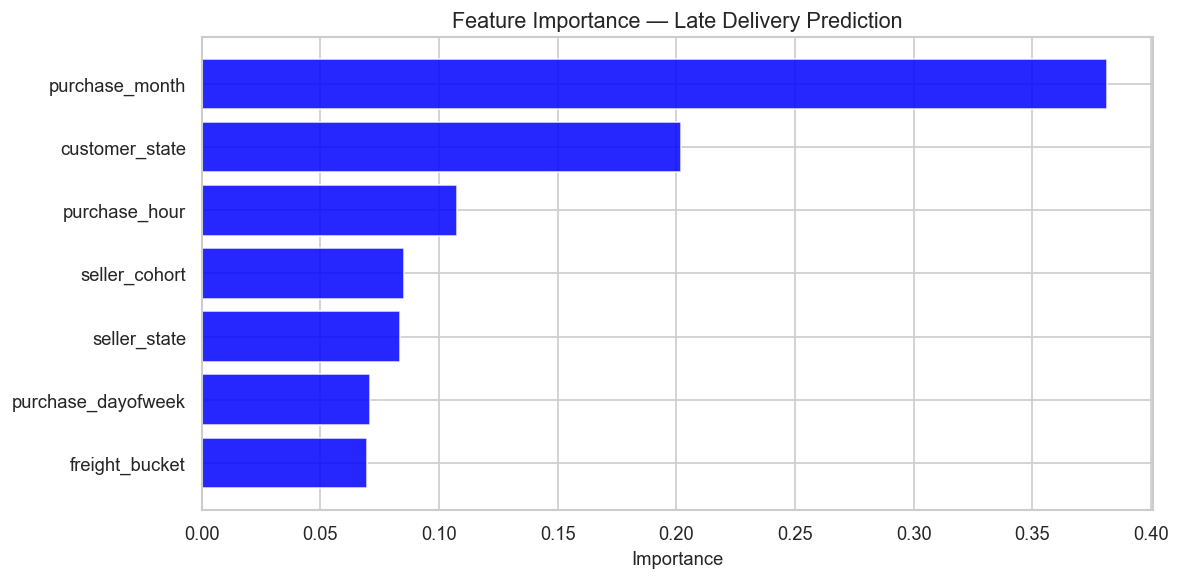


Feature Importance:
  purchase_month            : 0.3816
  customer_state            : 0.2021
  purchase_hour             : 0.1074
  seller_cohort             : 0.0853
  seller_state              : 0.0834
  purchase_dayofweek        : 0.0709
  freight_bucket            : 0.0694


In [202]:
# Feature importance
feat_imp = pd.DataFrame({
    'feature'   : features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='blue', alpha=0.85)
plt.xlabel('Importance')
plt.title('Feature Importance — Late Delivery Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nFeature Importance:')
for _, row in feat_imp.iterrows():
    print(f'  {row["feature"]:<25} : {row["importance"]:.4f}')

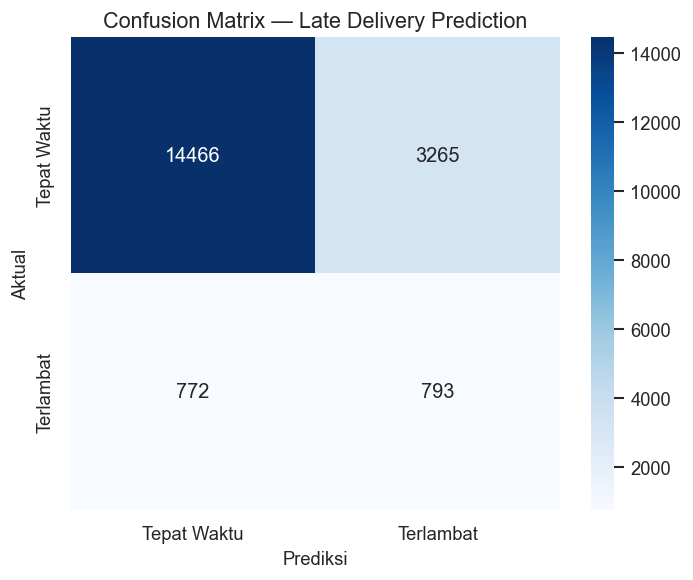

Algoritma     : Random Forest
ROC-AUC       : 0.7236
Recall (late) : 0.51 — model berhasil tangkap 51% order terlambat

Top 3 faktor penyebab keterlambatan:
  3. purchase_month (38.2%)
  1. customer_state (20.2%)
  5. purchase_hour (10.7%)


In [203]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tepat Waktu', 'Terlambat'], yticklabels=['Tepat Waktu', 'Terlambat'])
plt.title('Confusion Matrix — Late Delivery Prediction')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.show()

# Summary
print(f'Algoritma     : Random Forest')
print(f'ROC-AUC       : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'Recall (late) : {0.51:.2f} — model berhasil tangkap 51% order terlambat')
print(f'\nTop 3 faktor penyebab keterlambatan:')
for i, row in feat_imp.head(3).iterrows():
    print(f'  {i+1}. {row["feature"]} ({row["importance"]*100:.1f}%)')

In [204]:
from xgboost import XGBClassifier

# hitung scale_pos_weight untuk handle imbalanced data
# ratio = jumlah kelas negatif / jumlah kelas positif
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# evaluasi
print('-- XGBoost --')
print(f'\nROC-AUC Score : {roc_auc_score(y_test, y_pred_proba_xgb):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Tepat Waktu', 'Terlambat']))

# perbandingan kedua model
print('-- Perbandingan Model --')
print(f'Random Forest ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'XGBoost       ROC-AUC : {roc_auc_score(y_test, y_pred_proba_xgb):.4f}')

scale_pos_weight: 11.33
-- XGBoost --

ROC-AUC Score : 0.7378

Classification Report:
              precision    recall  f1-score   support

 Tepat Waktu       0.95      0.74      0.83     17731
   Terlambat       0.17      0.60      0.27      1565

    accuracy                           0.73     19296
   macro avg       0.56      0.67      0.55     19296
weighted avg       0.89      0.73      0.79     19296

-- Perbandingan Model --
Random Forest ROC-AUC : 0.7236
XGBoost       ROC-AUC : 0.7378


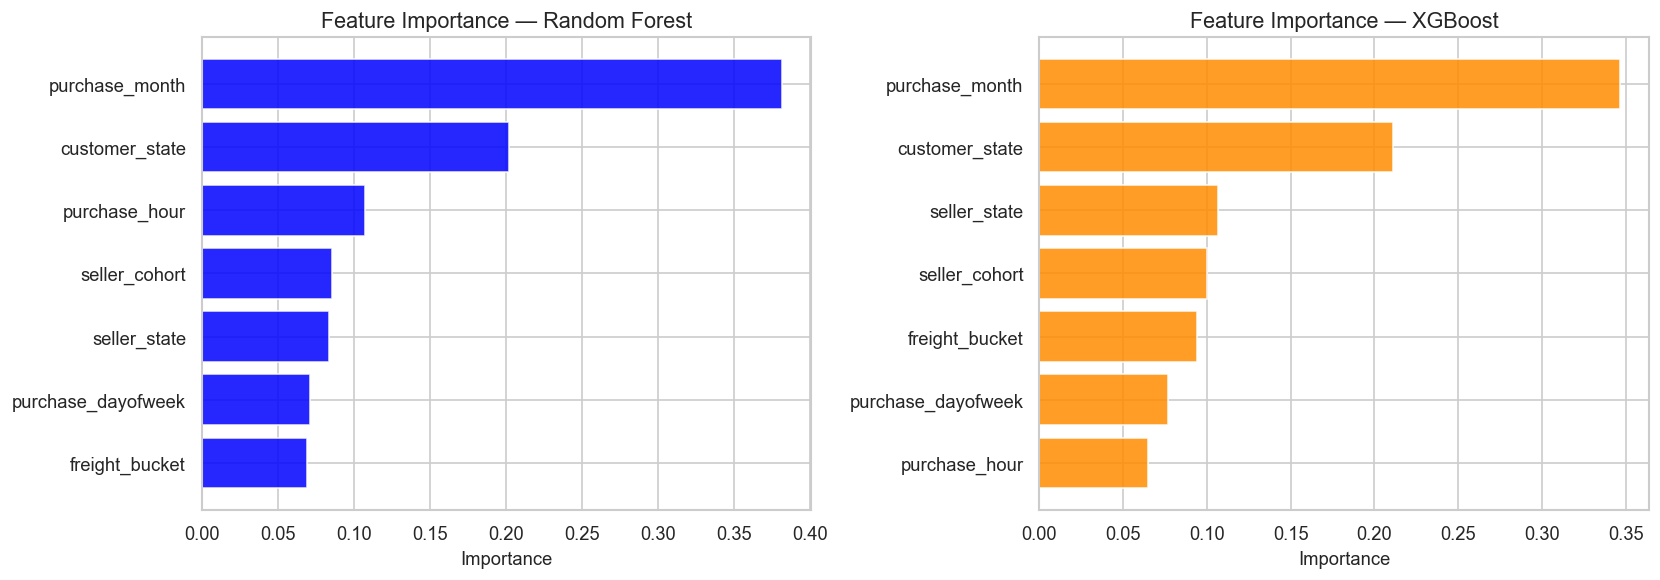

Feature Importance XGBoost:
  purchase_month            : 0.3464
  customer_state            : 0.2113
  seller_state              : 0.1066
  seller_cohort             : 0.0999
  freight_bucket            : 0.0942
  purchase_dayofweek        : 0.0764
  purchase_hour             : 0.0650


In [205]:
# feature importance XGBoost
feat_imp_xgb = pd.DataFrame({
    'feature'   : features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# feature importance RF
axes[0].barh(feat_imp['feature'], feat_imp['importance'], color='blue', alpha=0.85)
axes[0].set_title('Feature Importance — Random Forest')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# feature importance XGBoost
axes[1].barh(feat_imp_xgb['feature'], feat_imp_xgb['importance'], color='darkorange', alpha=0.85)
axes[1].set_title('Feature Importance — XGBoost')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('Feature Importance XGBoost:')
for _, row in feat_imp_xgb.iterrows():
    print(f'  {row["feature"]:<25} : {row["importance"]:.4f}')

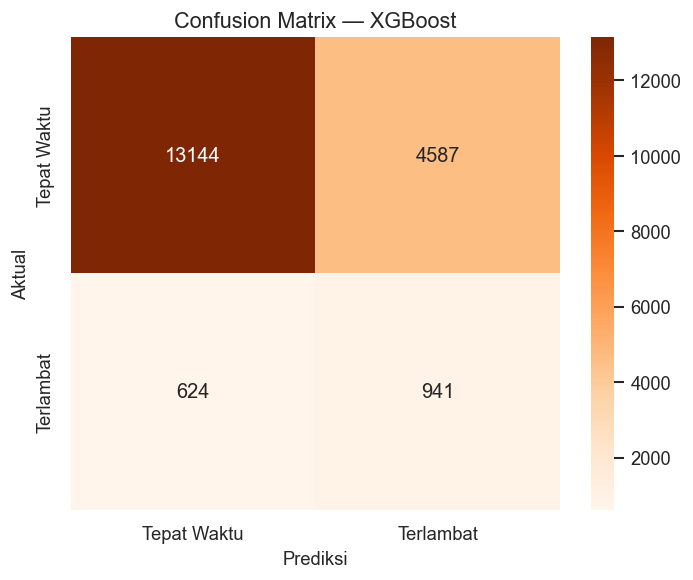

In [206]:
# Confusion Matrix XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=['Tepat Waktu', 'Terlambat'], yticklabels=['Tepat Waktu', 'Terlambat'])
plt.title('Confusion Matrix — XGBoost')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.show()

| | ROC-AUC | Recall (late) | Precision (late) | Deteksi benar | Terlewat | False alarm |
|---|---|---|---|---|---|---|
| Random Forest | 0.7236 | 51% | 20% | 793 | 772 | 3.265 |
| XGBoost | **0.7378** | **60%** | 17% | **941** | **624** | 4.587 |

In [ ]:
# simpan hasil prediksi ke dataframe
df_predictions = df_ml_clean.copy()
df_predictions['late_probability'] = xgb_model.predict_proba(X)[:, 1]
df_predictions['late_prediction'] = xgb_model.predict(X)
df_predictions['risk_level'] = pd.cut(
    df_predictions['late_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
).astype(str)

# tambahkan order_id
df_predictions['order_id'] = df_ml_clean.index.map(
    delivered.reset_index()['order_id']
)

# pilih kolom yang relevan
fact_late_risk = df_predictions[[
    'order_id',
    'customer_state',
    'seller_state',
    'seller_cohort',
    'purchase_month',
    'freight_bucket',
    'late_probability',
    'late_prediction',
    'risk_level',
    'is_late'
]].copy()

# konversi tipe
fact_late_risk['late_probability'] = fact_late_risk['late_probability'].round(4)
fact_late_risk['late_prediction'] = fact_late_risk['late_prediction'].astype(int)
fact_late_risk['is_late'] = fact_late_risk['is_late'].astype(int)

print(f'Total rows: {len(fact_late_risk):,}')
print(f'\nDistribusi risk level:')
print(fact_late_risk['risk_level'].value_counts())
print(f'\nSample:')
print(fact_late_risk.head(3))

Total rows: 96,478

Distribusi risk level:
risk_level
Medium Risk    49211
Low Risk       31050
High Risk      16217
Name: count, dtype: int64

Sample:
                           order_id customer_state seller_state seller_cohort  \
0  e481f51cbdc54678b7cc49136f2d6af7             SP           SP        2017Q3   
1  53cdb2fc8bc7dce0b6741e2150273451             BA           SP        2018Q1   
2  47770eb9100c2d0c44946d9cf07ec65d             GO           SP        2017Q1   

   purchase_month freight_bucket  late_probability  late_prediction  \
0              10   Sangat murah            0.4127                0   
1               7          Mahal            0.4181                0   
2               8          Mahal            0.2895                0   

    risk_level  is_late  
0  Medium Risk        0  
1  Medium Risk        0  
2     Low Risk        0  


---

### **Statistical Significance Testing | ML**

---

In [ ]:
# High Risk vs Low Risk prediction
high_risk = fact_late_risk[fact_late_risk['risk_level'] == 'High Risk']['is_late']
low_risk  = fact_late_risk[fact_late_risk['risk_level'] == 'Low Risk']['is_late']

tabel_5 = [
    [int((~high_risk.astype(bool)).sum()), int(high_risk.sum())],
    [int((~low_risk.astype(bool)).sum()),  int(low_risk.sum())]
]

chi2, p, dof, expected = chi2_contingency(tabel_5)

print('Uji — Late rate High Risk vs Low Risk prediction')
print(f'   High Risk: {high_risk.sum()} terlambat dari {len(high_risk)} order ({high_risk.mean()*100:.1f}%)')
print(f'   Low Risk : {low_risk.sum()} terlambat dari {len(low_risk)} order ({low_risk.mean()*100:.1f}%)')
print(f'   Chi-square : {chi2:.2f}')
print(f'   P-value    : {p:.6f}')
print(f'   Kesimpulan : {"Signifikan — model berhasil memisahkan risiko" if p < 0.05 else "Tidak signifikan"}')

Uji — Late rate High Risk vs Low Risk prediction
   High Risk: 4080 terlambat dari 16217 order (25.2%)
   Low Risk : 469 terlambat dari 31050 order (1.5%)
   Chi-square : 6846.86
   P-value    : 0.000000
   Kesimpulan : Signifikan — model berhasil memisahkan risiko


---

### **Model Explainability (SHAP)**

---

In [ ]:
import sys
!{sys.executable} -m pip install shap


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


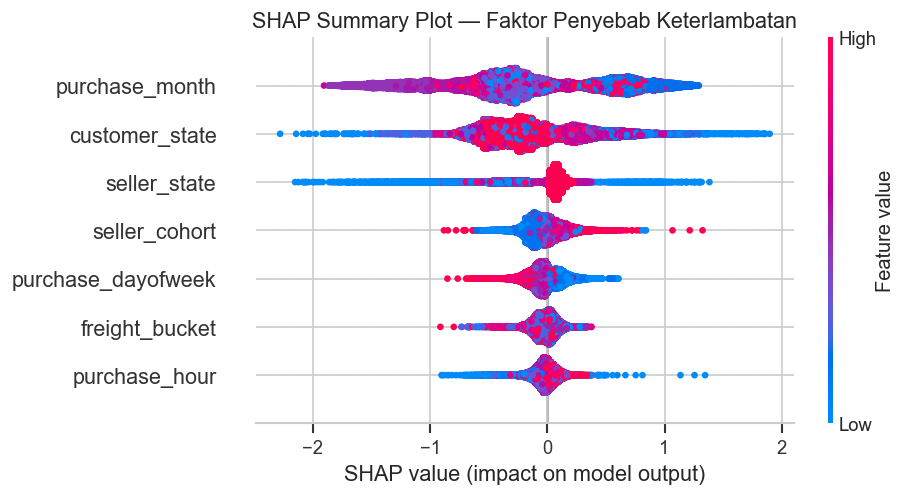

In [ ]:
import shap

# model XGBoost yang sudah ditraining sebelumnya
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_all)

# SHAP summary plot (global feature importance)
plt.figure()
shap.summary_plot(shap_values, X_all, feature_names=features, show=False)
plt.title('SHAP Summary Plot — Faktor Penyebab Keterlambatan')
plt.tight_layout()
plt.show()

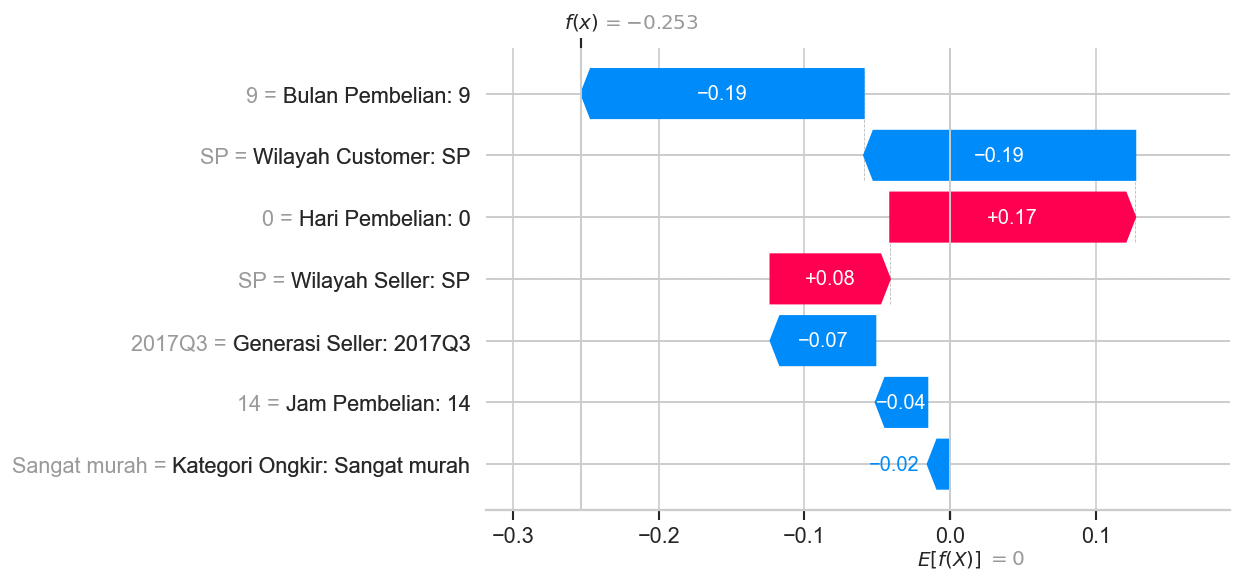

In [219]:
label_map = {
    'customer_state': 'Wilayah Customer',
    'seller_state': 'Wilayah Seller',
    'purchase_month': 'Bulan Pembelian',
    'purchase_dayofweek': 'Hari Pembelian',
    'purchase_hour': 'Jam Pembelian',
    'freight_bucket': 'Kategori Ongkir',
    'seller_cohort': 'Generasi Seller'
}

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=list(feature_display_named.values()),
    feature_names=[f"{label_map[k]}: {v}" for k, v in feature_display_named.items()]
)

shap.plots.waterfall(explanation, show=True)

Nilai fitur untuk order High Risk ini:
  customer_state: MG
  seller_state: SP
  purchase_month: 2
  purchase_dayofweek: 2
  purchase_hour: 17
  freight_bucket: Sedang
  seller_cohort: 2017Q2


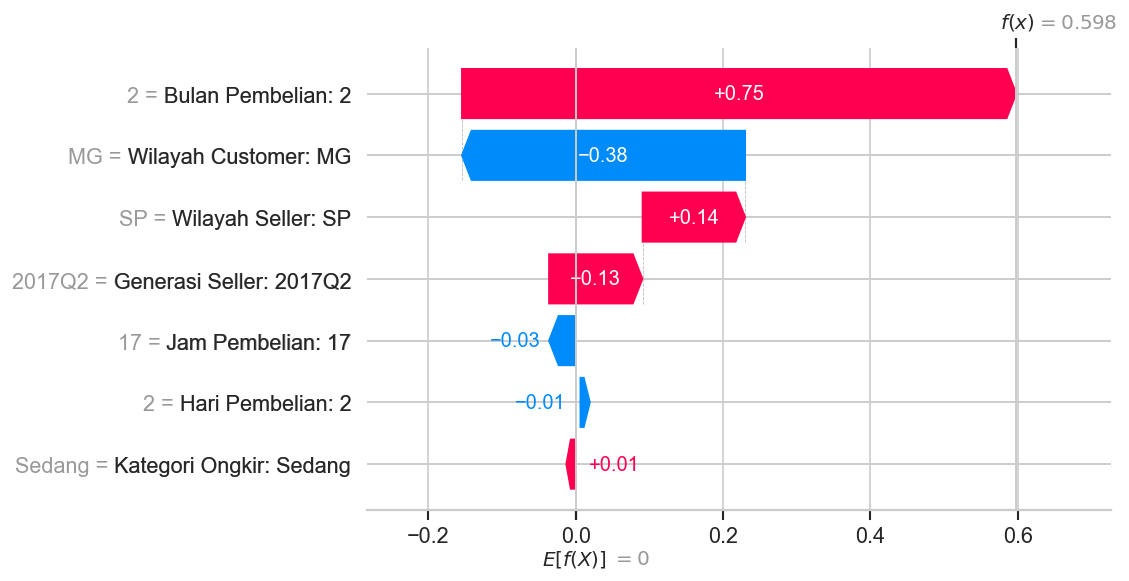

In [220]:
high_risk_late_idx = df_ml_clean[df_ml_clean['is_late'] == 1].index[10]
idx2 = df_ml_clean.index.get_loc(high_risk_late_idx)

# Decode label
feature_display_named2 = {}
for col in features:
    val = X_all.iloc[idx2][col]
    if col in le_dict:
        feature_display_named2[col] = le_dict[col].inverse_transform([int(val)])[0]
    else:
        feature_display_named2[col] = val

print("Nilai fitur untuk order High Risk ini:")
for k, v in feature_display_named2.items():
    print(f"  {k}: {v}")

explanation2 = shap.Explanation(
    values=shap_values[idx2],
    base_values=explainer.expected_value,
    data=list(feature_display_named2.values()),
    feature_names=[f"{label_map[k]}: {v}" for k, v in feature_display_named2.items()]
)

shap.plots.waterfall(explanation2, show=True)

kenapa model memprediksi suatu order berisiko terlambat atau tidak.

**Order tepat waktu (f(x) = -0.253):** Beli September di São Paulo — bulan dan wilayah yang aman, risiko rendah.

**Order terlambat (f(x) = 0.598):** Beli Februari di Minas Gerais — Februari peak season dengan kontribusi terbesar ke risiko (+0.75).

---

### **Estimasi Pengiriman per Wilayah**

---

percentile 75 — 75% order sampai dalam waktu ini

In [228]:
state_name_map = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AM': 'Amazonas', 'AP': 'Amapá',
    'BA': 'Bahia', 'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo',
    'GO': 'Goiás', 'MA': 'Maranhão', 'MG': 'Minas Gerais', 'MS': 'Mato Grosso do Sul',
    'MT': 'Mato Grosso', 'PA': 'Pará', 'PB': 'Paraíba', 'PE': 'Pernambuco',
    'PI': 'Piauí', 'PR': 'Paraná', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RO': 'Rondônia', 'RR': 'Roraima', 'RS': 'Rio Grande do Sul', 'SC': 'Santa Catarina',
    'SE': 'Sergipe', 'SP': 'São Paulo', 'TO': 'Tocantins'
}

estimasi = del_cust.groupby('customer_state').agg(
    estimasi_saat_ini = ('estimated_days', 'median'),
    aktual_median     = ('delivery_days', 'median'),
    aktual_p75        = ('delivery_days', lambda x: x.quantile(0.75)),
    aktual_p90        = ('delivery_days', lambda x: x.quantile(0.90)),
    total_order       = ('order_id', 'count')
).reset_index()

estimasi['wilayah'] = estimasi['customer_state'].map(state_name_map)
estimasi['rekomendasi_estimasi'] = estimasi['aktual_p75'].apply(lambda x: int(x) + 1)
estimasi['selisih_estimasi'] = estimasi['estimasi_saat_ini'] - estimasi['aktual_median']

estimasi = estimasi.sort_values('aktual_p75', ascending=False).reset_index(drop=True)

print("Rekomendasi Estimasi Pengiriman per Wilayah")
print("(berdasarkan percentile 75 data aktual)\n")
print(estimasi[['wilayah', 'estimasi_saat_ini', 'aktual_median', 'aktual_p75', 'rekomendasi_estimasi', 'total_order']].to_string(index=False))

Rekomendasi Estimasi Pengiriman per Wilayah
(berdasarkan percentile 75 data aktual)

            wilayah  estimasi_saat_ini  aktual_median  aktual_p75  rekomendasi_estimasi  total_order
           Amazonas               45.0           25.0       33.00                    34          145
            Roraima               44.0           25.0       32.00                    33           41
            Alagoas               31.0           22.0       30.00                    31          397
              Amapá               47.0           24.0       30.00                    31           67
               Pará               36.0           21.0       28.00                    29          946
           Maranhão               30.0           19.0       25.00                    26          717
              Ceará               31.0           18.0       25.00                    26         1279
            Paraíba               32.0           18.0       24.00                    25          517
      

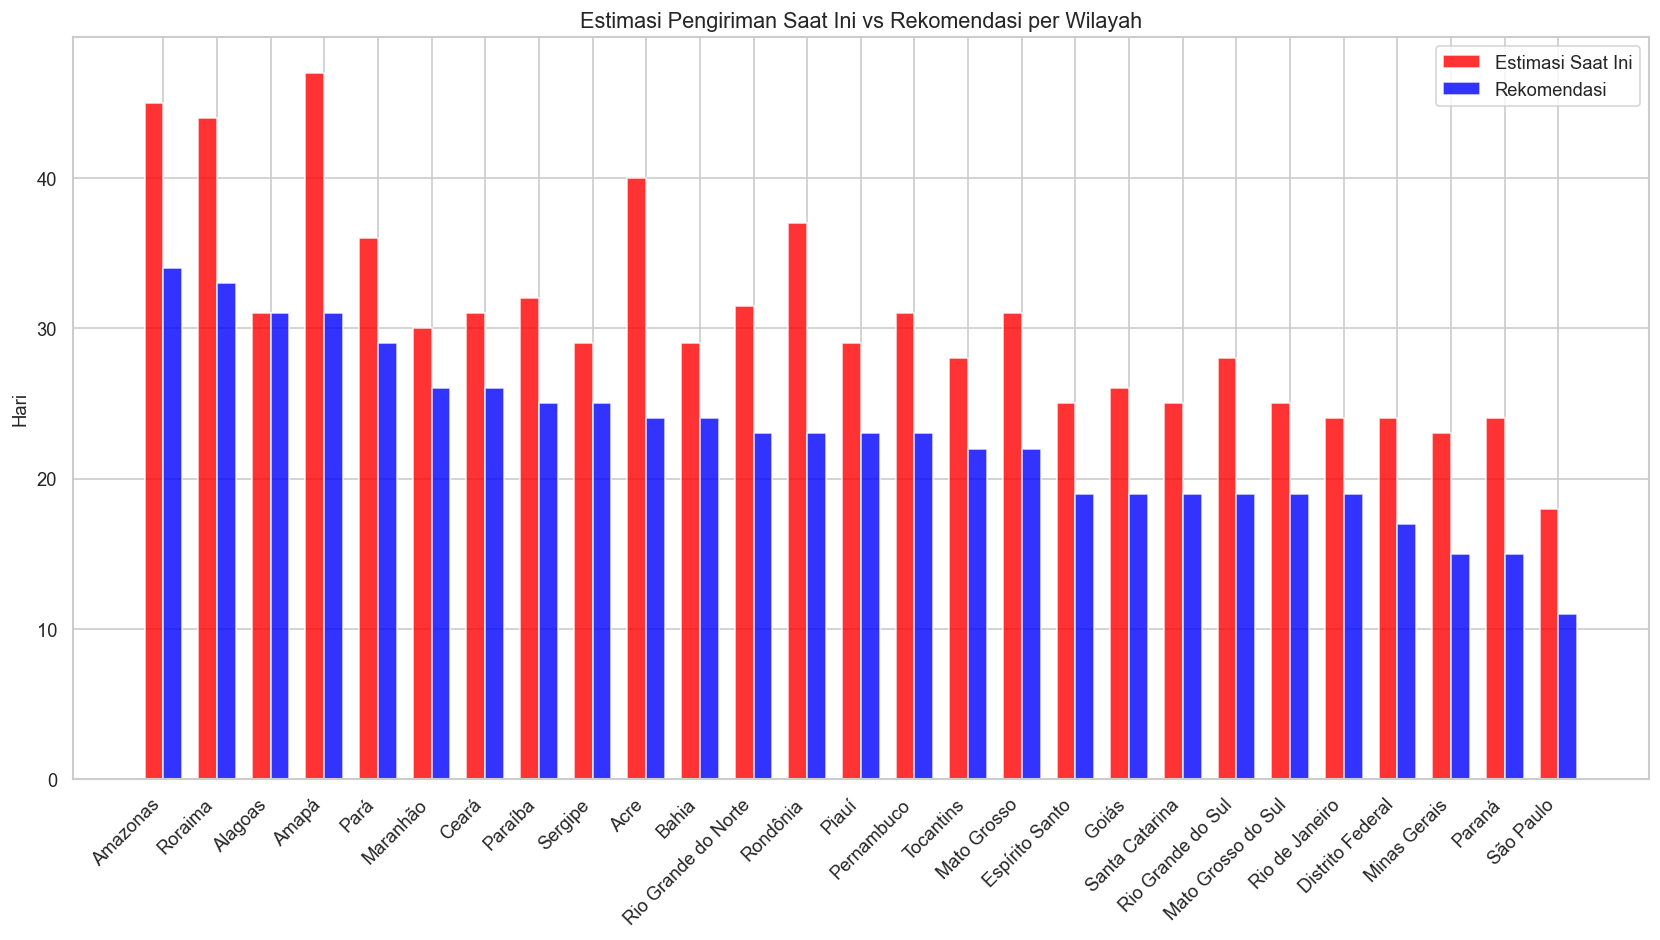

In [230]:
fig, ax = plt.subplots(figsize=(14, 8))

x = range(len(estimasi))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], estimasi['estimasi_saat_ini'], 
               width, label='Estimasi Saat Ini', color='red', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], estimasi['rekomendasi_estimasi'], 
               width, label='Rekomendasi', color='blue', alpha=0.8)

ax.set_xticks(range(len(estimasi)))
ax.set_xticklabels(estimasi['wilayah'], rotation=45, ha='right')
ax.set_ylabel('Hari')
ax.set_title('Estimasi Pengiriman Saat Ini vs Rekomendasi per Wilayah')
ax.legend()
plt.tight_layout()
plt.show()

Platform selama ini estimasikan pengiriman yang terlalu lama ke customer di semua wilayah. warna biru adalah estimasi realistis berdasarkan data aktual, kalau diterapkan SLA accuracy rate diperkirakan naik dari 0.53 mendekati 0.75.